# COMP1891 – Applications in AI and Data Science
## Jupyter Notebook Submission

**Module:** COMP1891 | **Module Leader:** Dr Nageena Frost | **University of Greenwich**

## Setup and Imports

In [1]:
import sys
# Install any missing packages (safe to re-run)
# !{sys.executable} -m pip install torch torchvision transformers scikit-learn pandas numpy matplotlib seaborn scipy pillow opencv-python --quiet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings, os, glob, json
from pathlib import Path

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, silhouette_score,
    balanced_accuracy_score
)
from PIL import Image

# ── Configuration ─────────────────────────────────────────────────────────────
# Every tunable constant lives here rather than inline, so an assumption can be
# changed in one place and the notebook re-run without hunting through cells.
SEED            = 42        # single seed for every stochastic step
TEST_SIZE       = 0.25      # hold-out fraction for the classification tasks
PRIMARY_SPLIT   = 0.20      # B1 reporting split, fixed BEFORE seeing any result
IQR_K_PRICE     = 1.5       # outlier fence for price
IQR_K_AREA      = 3.0       # looser fence for the right-skewed area columns
VIF_THRESHOLD   = 5.0       # above this a coefficient is treated as unstable
CONF_THRESHOLD  = 0.40      # C1: below this a prediction is sent for review
STRESS_LEVEL    = 0.55      # C2: weekly mean stress that triggers review
STRESS_TREND    = 0.15      # C2: first-to-last-week rise that triggers review
RATING_BANDS    = [(4, 'Low (<=4)'), (6, 'Mid (5-6)')]   # upper bound -> label
BAND_HIGH       = 'High (>=7)'

DATA_DIR = Path('Datasets')
FIG_DIR  = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

np.random.seed(SEED)

def save_fig(name):
    """Save the current figure into FIG_DIR under a consistent name."""
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')

# Only silence the specific, expected warnings. A blanket ignore would hide the
# undefined-metric warnings raised by zero-support classes, which are real signal
# about the imbalance analysed in Section A3.6.
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
# The seaborn-whitegrid style draws box-plot lines in white, which makes the
# boxes invisible on a white canvas. Force dark box lines for every figure.
plt.rcParams.update({
    'boxplot.boxprops.color':        '#2c3e50',
    'boxplot.whiskerprops.color':    '#2c3e50',
    'boxplot.capprops.color':        '#2c3e50',
    'boxplot.medianprops.color':     '#e74c3c',
    'boxplot.medianprops.linewidth': 1.6,
    'boxplot.flierprops.markeredgecolor': '#7f8c8d',
})
%matplotlib inline
print(f"Libraries loaded. SEED={SEED}, figures -> {FIG_DIR}/")


Libraries loaded. SEED=42, figures -> figures/


## Data Loading and Column Setup
Auto-detects the CSV delimiter and column names. Cleans numeric formatting issues
(currency symbols, comma thousands separators, European decimal notation).


In [3]:
# ── Load CSV with auto-detected delimiter ────────────────────────────────────
CSV_PATH = 'Datasets/Estate_Agent.csv'

# Some count columns store values as words (e.g. Parking = 'Two'). Without this
# map they become NaN and the real value is lost during imputation.
WORD_NUM = {'zero':0,'one':1,'two':2,'three':3,'four':4,'five':5,
            'six':6,'seven':7,'eight':8,'nine':9,'ten':10}

def clean_numeric(series, report=False):
    s = series.astype(str).str.strip()
    s = s.str.replace(r'[£$€\s]', '', regex=True)   # remove currency/space
    s = s.str.replace(',', '', regex=False)             # remove thousands commas
    s = s.replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    words = s.str.lower().isin(WORD_NUM)                # e.g. 'Two' -> 2
    if report and words.sum():
        print(f"  '{series.name}': converted {words.sum()} written-out "
              f"number(s) {sorted(set(s[words]))}")
    s = s.mask(words, s.str.lower().map(WORD_NUM))
    return pd.to_numeric(s, errors='coerce')

def detect_col(df, keywords, exclude=None):
    exclude = set(exclude or [])
    for kw in keywords:
        for col in df.columns:
            if col in exclude: continue
            if kw.lower() == col.lower().strip(): return col
    for kw in keywords:
        for col in df.columns:
            if col in exclude: continue
            if kw.lower() in col.lower().strip(): return col
    return None

if os.path.exists(CSV_PATH):
    with open(CSV_PATH, 'r', encoding='utf-8', errors='replace') as f:
        first_line = f.readline()
    sep = ';' if first_line.count(';') > first_line.count(',') else ','
    print(f"Detected delimiter: '{sep}'")
    df_raw = pd.read_csv(CSV_PATH, sep=sep)
    df_raw.columns = df_raw.columns.str.strip()
    print(f"Loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
    print("Columns:", df_raw.columns.tolist())
else:
    print("Estate_Agent.csv not found — generating synthetic data.")
    np.random.seed(42)
    n = 260
    rating = np.random.choice([1,2,3,4,5], n, p=[0.05,0.15,0.35,0.30,0.15])
    living = np.random.randint(800, 5000, n).astype(float)
    land   = np.random.randint(2000, 15000, n).astype(float)
    beds   = np.random.randint(1, 7, n)
    baths  = np.random.randint(1, 5, n)
    garage = np.random.randint(0, 1200, n).astype(float)
    cars   = np.random.randint(0, 4, n)
    year   = np.random.randint(1960, 2023, n)
    price  = (180*living + 40*land + 25000*beds + 20000*baths
              + 80*garage + 5000*rating + np.random.normal(0, 40000, n)).clip(50000, 2000000)
    df_raw = pd.DataFrame({'LandArea': land, 'YearBuilt': year, 'Bathrooms': baths,
                           'Bedrooms': beds, 'GarageArea': garage, 'LivingArea': living,
                           'Rating': rating, 'ParkingCars': cars, 'Price': price})
    idx = np.random.choice(n, 22, replace=False)
    df_raw.loc[idx[:7],  'GarageArea'] = np.nan
    df_raw.loc[idx[7:12],'Bathrooms']  = np.nan
    df_raw.loc[idx[12:],  'Price']     = np.nan
    df_raw = pd.concat([df_raw, df_raw.iloc[[0,5,10]]], ignore_index=True)
    df_raw.loc[258, 'Price'] = 9_999_999
    df_raw.loc[259, 'LivingArea'] = -500

df_raw.head()


Detected delimiter: ';'
Loaded: 350 rows x 9 columns
Columns: ['House_Area', 'Build', 'No_of_Bathrooms', 'No_of_Bedrooms', 'Garage_Area', 'Living_Space', 'Rating', 'Parking', 'House_Price']


,House_Area,Build,No_of_Bathrooms,No_of_Bedrooms,Garage_Area,Living_Space,Rating,Parking,House_Price
0,9550,1915,1.0,3.0,642.0,961.0,5,3,140500
1,14260,2000,2.0,4.0,836.0,1145.0,5,3,250000
2,14115,1993,1.0,1.0,480.0,796.0,5,2,143000
3,10084,2004,2.0,3.0,636.0,1694.0,5,2,277000
4,10382,1973,2.0,3.0,484.0,1107.0,6,2,205000


In [4]:
# ── Detect column roles ───────────────────────────────────────────────────────
target_col  = detect_col(df_raw, ['price', 'saleprice', 'sale_price', 'houseprice'])
rating_col  = detect_col(df_raw, ['rating', 'overallqual', 'quality', 'grade', 'houserating'], [target_col])
beds_col    = detect_col(df_raw, ['bedroom', 'bedrooms', 'bed', 'bedroomabvgr'])
baths_col   = detect_col(df_raw, ['bathroom', 'bathrooms', 'bath', 'fullbath'])
living_col  = detect_col(df_raw, ['livingarea', 'grlivarea', 'living', 'livarea', 'livingspace'])
land_col    = detect_col(df_raw, ['landarea', 'lotarea', 'land', 'lot', 'area'])
garage_col  = detect_col(df_raw, ['garagearea', 'garage'])
cars_col    = detect_col(df_raw, ['parkingcars', 'garagecars', 'parking', 'cars'])
year_col    = detect_col(df_raw, ['yearbuilt', 'year_built', 'year', 'build', 'built', 'yr'])

print("Column mapping detected:")
print(f"  Price (target) : {target_col}")
print(f"  Rating         : {rating_col}")
print(f"  Bedrooms       : {beds_col}")
print(f"  Bathrooms      : {baths_col}")
print(f"  Living Area    : {living_col}")
print(f"  Land Area      : {land_col}")
print(f"  Garage Area    : {garage_col}")
print(f"  Parking Cars   : {cars_col}")
print(f"  Year Built     : {year_col}")

feature_cols = [c for c in [land_col, year_col, baths_col, beds_col,
                              garage_col, living_col, cars_col] if c is not None]
print(f"\nFeature columns for ML: {feature_cols}")


Column mapping detected:
  Price (target) : House_Price
  Rating         : Rating
  Bedrooms       : No_of_Bedrooms
  Bathrooms      : No_of_Bathrooms
  Living Area    : Living_Space
  Land Area      : House_Area
  Garage Area    : Garage_Area
  Parking Cars   : Parking
  Year Built     : Build

Feature columns for ML: ['House_Area', 'Build', 'No_of_Bathrooms', 'No_of_Bedrooms', 'Garage_Area', 'Living_Space', 'Parking']


In [5]:
# ── Clean all numeric columns ─────────────────────────────────────────────────
df_raw_clean = df_raw.copy()
print("Formatting issues corrected:")
for col in df_raw_clean.columns:
    df_raw_clean[col] = clean_numeric(df_raw_clean[col], report=True)

print("Cleaned dtypes:")
print(df_raw_clean.dtypes)
print(f"\nPrice sample (first 5): {df_raw_clean[target_col].dropna().head().tolist()}")


Formatting issues corrected:
  'Parking': converted 9 written-out number(s) ['One', 'Three', 'Two']
Cleaned dtypes:
House_Area           int64
Build                int64
No_of_Bathrooms    float64
No_of_Bedrooms     float64
Garage_Area        float64
Living_Space       float64
Rating               int64
Parking            float64
House_Price          int64
dtype: object

Price sample (first 5): [140500, 250000, 143000, 277000, 205000]


---
## Section A: Data Science – Scenario 1 (Estate Agent Dataset)
**[30% of total marks]**


### A1 – Exploratory Data Analysis (EDA)
Examine statistical properties and identify relevant features. All numeric columns
describing property characteristics are included; the target is the price column.


In [6]:
# A1.1 – Dataset overview
print(f"Shape: {df_raw_clean.shape[0]} rows, {df_raw_clean.shape[1]} columns\n")
print("Column data types:")
print(df_raw_clean.dtypes)


Shape: 350 rows, 9 columns

Column data types:
House_Area           int64
Build                int64
No_of_Bathrooms    float64
No_of_Bedrooms     float64
Garage_Area        float64
Living_Space       float64
Rating               int64
Parking            float64
House_Price          int64
dtype: object


In [7]:
# A1.2 – Descriptive statistics
df_raw_clean.describe().round(2)


,House_Area,Build,No_of_Bathrooms,No_of_Bedrooms,Garage_Area,Living_Space,Rating,Parking,House_Price
count,350.00,350.00,348.00,348.00,347.00,345.00,350.00,350.00,350.00
mean,10474.01,1971.71,1.56,2.84,463.67,1153.18,5.53,1.72,180908.61
std,9525.63,29.95,0.56,0.80,210.46,353.86,1.13,0.76,75814.80
min,1596.00,1880.00,0.00,0.00,0.00,483.00,2.00,0.00,40000.00
25%,7588.50,1954.00,1.00,2.00,322.00,884.00,5.00,1.00,129600.00
50%,9378.50,1975.00,2.00,3.00,468.00,1097.00,5.00,2.00,163745.00
75%,11637.75,2001.00,2.00,3.00,576.00,1362.00,6.00,2.00,214750.00
max,159000.00,2010.00,3.00,6.00,1166.00,2392.00,9.00,3.00,501837.00


In [8]:
# A1.3 – Missing value summary
missing = df_raw_clean.isnull().sum()
pct     = (missing / len(df_raw_clean) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]
print("=== Missing Values ===")
print(miss_df if not miss_df.empty else "No missing values.")


=== Missing Values ===
                 Missing Count  Missing %
No_of_Bathrooms              2       0.57
No_of_Bedrooms               2       0.57
Garage_Area                  3       0.86
Living_Space                 5       1.43


Numeric columns: ['House_Area', 'Build', 'No_of_Bathrooms', 'No_of_Bedrooms', 'Garage_Area', 'Living_Space', 'Rating', 'Parking', 'House_Price']


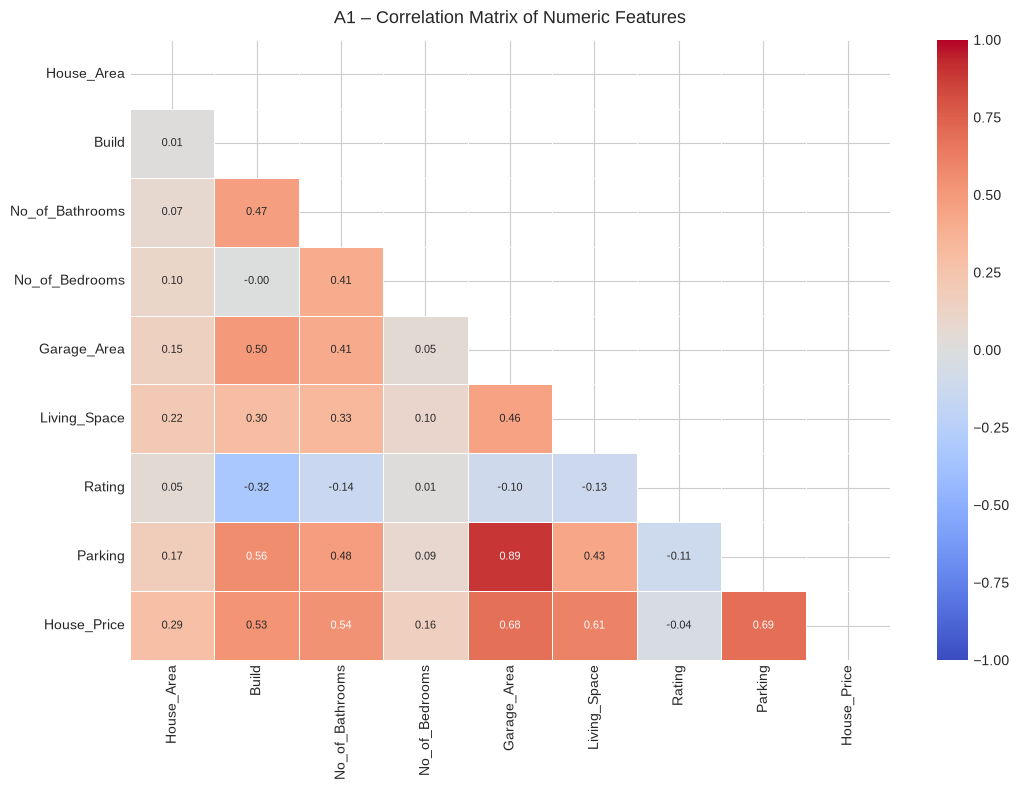

In [9]:
# A1.4 – Correlation heatmap
num_cols = df_raw_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {num_cols}")
corr = df_raw_clean[num_cols].corr()
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('A1 – Correlation Matrix of Numeric Features', fontsize=13, pad=12)
plt.tight_layout()
save_fig('A1_correlation_heatmap')
plt.show()


In [10]:
# A1.5 - Feature selection: which columns belong in the analysis, and why
# Each candidate is judged on three tests: does it describe the property itself,
# does it carry signal against price, and is it a proxy for a protected
# characteristic (which would make the model unlawful to deploy, see Section D).
corr_to_price = df_raw_clean.corr(numeric_only=True)[target_col].drop(target_col)

role = {}
for c in df_raw_clean.columns:
    if c == target_col:      role[c] = 'Target (regression)'
    elif c == rating_col:    role[c] = 'Target (classification)'
    elif c in feature_cols:  role[c] = 'Predictor'
    else:                    role[c] = 'Excluded'

selection = pd.DataFrame({
    'Role': pd.Series(role),
    'r with price': corr_to_price.round(3),
    'Distinct values': df_raw_clean.nunique(),
    'Missing %': (df_raw_clean.isna().mean() * 100).round(2),
})
selection['Decision'] = np.where(
    selection['Role'] == 'Predictor', 'Include - physical attribute with signal',
    np.where(selection['Role'].str.startswith('Target'), 'Modelled as target', 'Not used'))
print("=== A1.5 Feature selection ===")
print(selection.to_string())

print(f'''
Rationale:
  * All seven physical attributes are retained. Every one correlates with price at
    |r| >= 0.15, so none is uninformative, and each describes the property rather
    than the people in it.
  * {rating_col} is NOT used to predict price. It correlates at r =
    {corr_to_price[rating_col]:.3f} - effectively zero - and is a subjective grade
    rather than a measurement, so it would inject human judgement into a model the
    agency wants to use to benchmark that very judgement. It is instead modelled as
    a target in its own right in Sections B2 and B3.
  * No proxy for a protected characteristic is present: the file carries no postcode,
    neighbourhood, demographic or name column. Had it done so, including it would risk
    indirect discrimination under the Equality Act 2010 (see Section D1).''')


=== A1.5 Feature selection ===
                                    Role  r with price  Distinct values  Missing %                                  Decision
Build                          Predictor         0.530               92       0.00  Include - physical attribute with signal
Garage_Area                    Predictor         0.681              190       0.86  Include - physical attribute with signal
House_Area                     Predictor         0.288              310       0.00  Include - physical attribute with signal
House_Price          Target (regression)           NaN              247       0.00                        Modelled as target
Living_Space                   Predictor         0.606              269       1.43  Include - physical attribute with signal
No_of_Bathrooms                Predictor         0.536                4       0.57  Include - physical attribute with signal
No_of_Bedrooms                 Predictor         0.162                7       0.57  Include - 

### A2 – Data Cleaning
Addresses duplicates, numeric type conversion, missing value imputation,
outlier removal (IQR), and illogical values.


In [11]:
# A2.1 - Cleaning as one pure function
# Each cleaning step is a transformation from the raw frame to a new frame. The
# function never mutates its input and never depends on a previously-run cell,
# so re-running this cell any number of times gives an identical result. The
# earlier in-place style (df = df[...]) recomputed the IQR from already-trimmed
# data, so running it twice silently removed more rows each time.
def iqr_bounds(s, k):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)

def clean_dataset(raw, verbose=True):
    """Return a cleaned copy of `raw` plus a log of what was changed."""
    out, log = raw.copy(), []

    n0 = len(out)
    out = out.drop_duplicates()
    log.append(('Duplicates removed', n0 - len(out)))

    # Price: standard fence. Area columns: looser fence, because large plots are
    # genuine rather than erroneous and a 1.5*IQR rule discards valid records.
    fences = [(target_col, IQR_K_PRICE)]
    fences += [(c, IQR_K_AREA) for c in (land_col, living_col, garage_col)
               if c and c in out.columns]
    for col, k in fences:
        lo, hi = iqr_bounds(out[col], k)
        mask = (out[col] < lo) | (out[col] > hi)
        if mask.sum():
            log.append((f'{col} outliers removed (k={k})', int(mask.sum())))
            out = out[~mask]

    for col in [c for c in (living_col, land_col, garage_col, target_col)
                if c and c in out.columns]:
        bad = (out[col] < 0).sum()
        if bad:
            log.append((f'{col} negative values removed', int(bad)))
            out = out[out[col] >= 0]

    if verbose:
        print(f"Rows: {n0} -> {len(out)} ({n0 - len(out)} removed, "
              f"{(n0 - len(out)) / n0 * 100:.1f}%)")
        for what, n in log:
            print(f"  {what}: {n}")
    return out.reset_index(drop=True), log

# Missing values are deliberately NOT imputed here. Imputing across the whole
# dataset would leak information from the hold-out rows into training; the
# imputer is instead fitted inside the model pipelines in Section B, where it
# refits on the training fold only. Section A2.2 shows the imputation itself.
df, clean_log = clean_dataset(df_raw_clean)

# Data contract: state the invariants so a silent regression fails loudly.
assert df[target_col].notna().all(),      'price must never be missing after cleaning'
assert (df[target_col] > 0).all(),        'price must be positive'
assert not df.duplicated().any(),         'duplicates must be gone'
# Parking held 9 values written as words; if the word-mapping in clean_numeric
# regresses they silently become NaN, so assert the column is fully populated.
assert df[cars_col].notna().all(),        'Parking must have no NaN (word forms must convert)'
assert len(df) > 0.9 * len(df_raw_clean.drop_duplicates()), 'cleaning must not gut the dataset'
print("\nData contract checks passed.")


Rows: 350 -> 327 (23 removed, 6.6%)
  Duplicates removed: 4
  House_Price outliers removed (k=1.5): 14
  House_Area outliers removed (k=3.0): 5

Data contract checks passed.


In [12]:
# A2.2 - Missing values
# The counts below drive the imputation strategy. The imputation itself is
# applied inside the Section B pipelines (fitted per training fold), and here on
# a separate copy used only for the exploratory charts in A3, which need a
# complete frame.
missing = df.isna().sum()
missing = missing[missing > 0]
print("=== Missing values after cleaning ===")
print(missing.to_string() if len(missing) else "None")

print("\nStrategy: median imputation. The area columns are right-skewed, so the "
      "median is not dragged upward by large properties the way the mean is.")
for col in missing.index:
    print(f"  '{col}': {missing[col]} missing -> median {df[col].median():.2f}")

# Frame used for visualisation only; models never see this one.
df_viz = df.fillna(df.median(numeric_only=True))
assert df_viz.isna().sum().sum() == 0, 'visualisation frame must be complete'
print(f"\nVisualisation frame complete: {df_viz.shape[0]} rows, no missing values.")


=== Missing values after cleaning ===
No_of_Bathrooms    2
No_of_Bedrooms     2
Garage_Area        3
Living_Space       4

Strategy: median imputation. The area columns are right-skewed, so the median is not dragged upward by large properties the way the mean is.
  'No_of_Bathrooms': 2 missing -> median 2.00
  'No_of_Bedrooms': 2 missing -> median 3.00
  'Garage_Area': 3 missing -> median 452.00
  'Living_Space': 4 missing -> median 1080.00

Visualisation frame complete: 327 rows, no missing values.


=== Outlier audit on the raw data ===
      Column   k   Lower  Upper  Outliers  % rows
 House_Price 1.5    1875 342475        14     4.0
 House_Price 3.0 -125850 470200         2     0.6
  House_Area 1.5    1515  17712        15     4.3
  House_Area 3.0   -4559  23786         6     1.7
Living_Space 1.5     167   2079         5     1.4
Living_Space 3.0    -550   2796         0     0.0
 Garage_Area 1.5     -59    957         3     0.9
 Garage_Area 3.0    -440   1338         0     0.0

Applied: k=1.5 on House_Price, k=3.0 on the area columns.


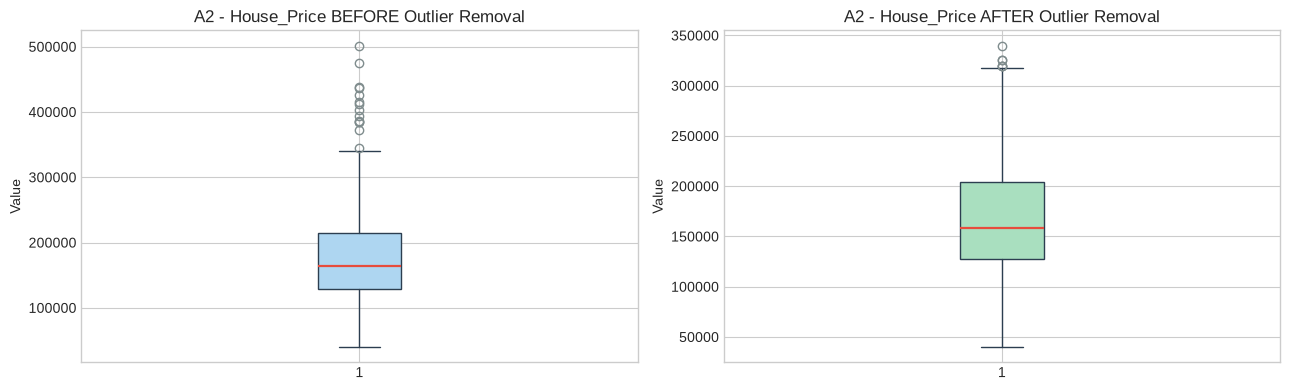

In [13]:
# A2.3 - Outlier audit
# The audit is reported at both fences so the choice made in clean_dataset() is
# evidenced rather than asserted.
cont_cols = [c for c in [target_col, land_col, living_col, garage_col]
             if c and c in df_raw_clean.columns]
audit = []
for c in cont_cols:
    for k in (IQR_K_PRICE, IQR_K_AREA):
        lo, hi = iqr_bounds(df_raw_clean[c], k)
        m = (df_raw_clean[c] < lo) | (df_raw_clean[c] > hi)
        audit.append({'Column': c, 'k': k, 'Lower': round(lo), 'Upper': round(hi),
                      'Outliers': int(m.sum()), '% rows': round(m.mean() * 100, 1)})
print("=== Outlier audit on the raw data ===")
print(pd.DataFrame(audit).to_string(index=False))
print(f"\nApplied: k={IQR_K_PRICE} on {target_col}, k={IQR_K_AREA} on the area columns.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, frame, title, colour in [
        (axes[0], df_raw_clean, 'BEFORE Outlier Removal', '#aed6f1'),
        (axes[1], df,           'AFTER Outlier Removal',  '#a9dfbf')]:
    ax.boxplot(frame[target_col].dropna(), patch_artist=True,
               boxprops={'facecolor': colour, 'edgecolor': '#2c3e50'})
    ax.set_title(f'A2 - {target_col} {title}')
    ax.set_ylabel('Value')
plt.tight_layout()
save_fig('A2_outlier_boxplot')
plt.show()


In [14]:
# A2.4 - Cleaned dataset summary
df.describe().round(2)


,House_Area,Build,No_of_Bathrooms,No_of_Bedrooms,Garage_Area,Living_Space,Rating,Parking,House_Price
count,327.00,327.00,325.00,325.00,324.00,323.00,327.00,327.00,327.00
mean,9431.79,1970.86,1.54,2.84,446.03,1125.55,5.54,1.66,170002.72
std,3449.77,29.58,0.55,0.77,200.48,333.39,1.11,0.73,59543.63
min,1596.00,1880.00,0.00,0.00,0.00,483.00,2.00,0.00,40000.00
25%,7486.00,1953.00,1.00,2.00,311.25,879.00,5.00,1.00,127750.00
50%,9180.00,1972.00,2.00,3.00,452.00,1080.00,5.00,2.00,158000.00
75%,11171.50,1999.50,2.00,3.00,572.00,1325.50,6.00,2.00,204375.00
max,21453.00,2009.00,3.00,6.00,1053.00,2259.00,9.00,3.00,340000.00


### A3 – Data Visualisation
Charts reveal distribution shapes, inter-feature relationships, and how features
relate to the target price variable.


Valid price values: 327
Range: 40,000 to 340,000


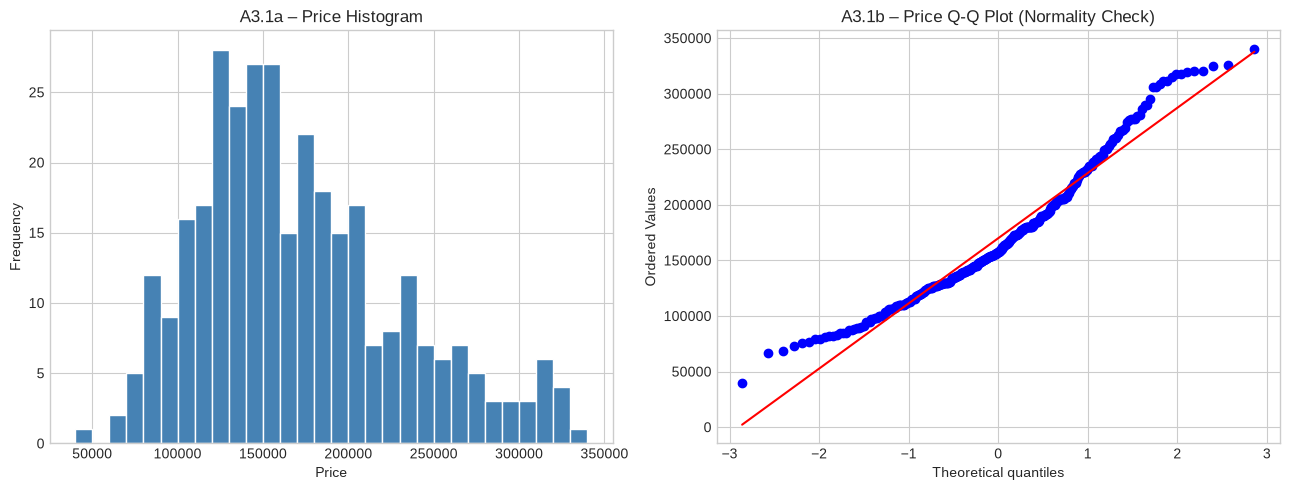

Price skewness: 0.707  (|skew| > 1 suggests right-skew)


In [15]:
# A3.1 – Price histogram and Q-Q plot
# Justification: Price is the regression target. Skewness assessment guides
# whether log-transformation is needed before modelling.
price_data = df_viz[target_col].dropna()
print(f"Valid price values: {len(price_data)}")
print(f"Range: {price_data.min():,.0f} to {price_data.max():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(price_data, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('A3.1a – Price Histogram')
axes[0].set_xlabel('Price'); axes[0].set_ylabel('Frequency')
stats.probplot(price_data, plot=axes[1])
axes[1].set_title('A3.1b – Price Q-Q Plot (Normality Check)')
plt.tight_layout()
save_fig('A3_price_distribution')
plt.show()
print(f"Price skewness: {price_data.skew():.3f}  (|skew| > 1 suggests right-skew)")


Discrete (count) features : ['No_of_Bathrooms', 'No_of_Bedrooms', 'Rating', 'Parking']
Continuous features       : ['House_Area', 'Build', 'Garage_Area', 'Living_Space']


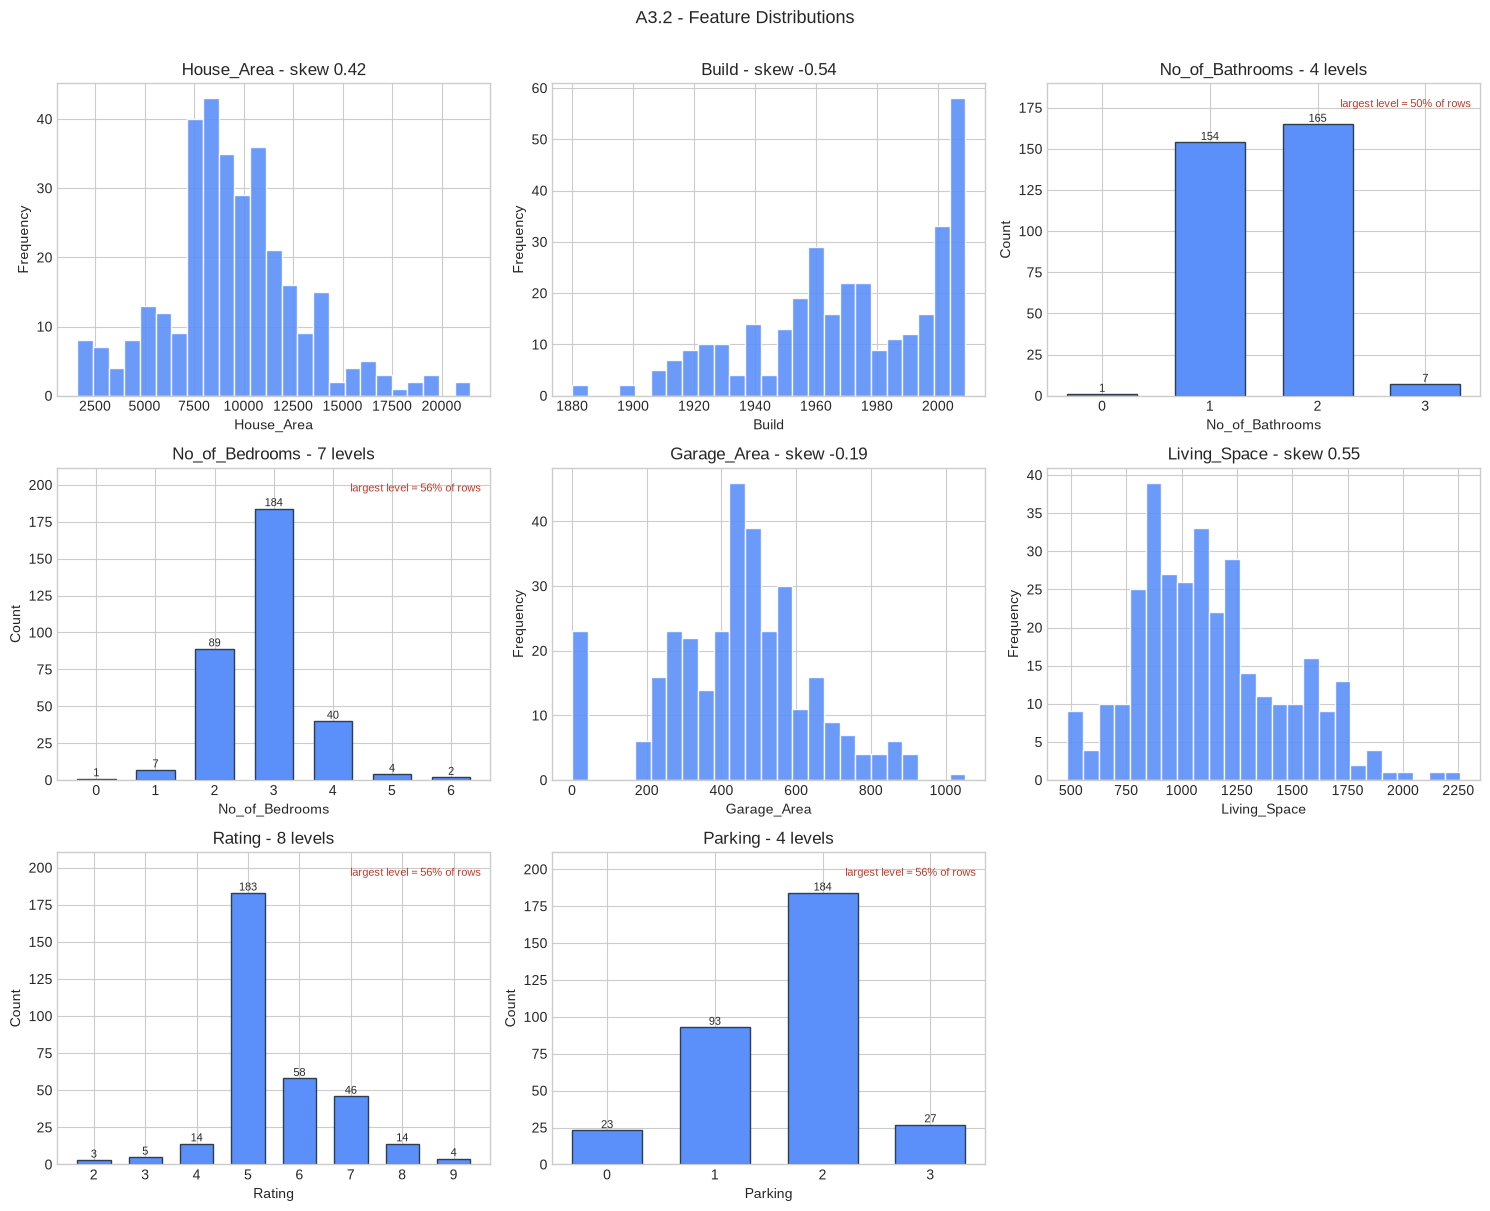

In [16]:
# A3.2 - Feature distributions
# Justification: distribution shape drives preprocessing choices. Count features
# (bedrooms, bathrooms, rating, parking) take only a handful of whole-number
# values, so a histogram invents meaningless fractional bins and hides class
# imbalance - those are drawn as category bars instead. Continuous features keep
# histograms, annotated with skewness.
num_feats = [c for c in df_viz.select_dtypes(include=[np.number]).columns if c != target_col]

def is_discrete(s, max_levels=12):
    v = s.dropna()
    return v.nunique() <= max_levels and np.allclose(v, v.round())

discrete   = [c for c in num_feats if is_discrete(df_viz[c])]
continuous = [c for c in num_feats if c not in discrete]
print(f"Discrete (count) features : {discrete}")
print(f"Continuous features       : {continuous}")

n_cols = 3
n_rows = max(1, (len(num_feats) + n_cols - 1) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(num_feats):
    ax = axes[i]
    if col in discrete:
        counts = df_viz[col].dropna().astype(int).value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values,
               color='#5b8ff9', edgecolor='#2c3e50', width=0.65)
        for xi, yi in zip(range(len(counts)), counts.values):
            ax.text(xi, yi, str(yi), ha='center', va='bottom', fontsize=8)
        share = counts.max() / counts.sum()
        ax.set_title(f'{col} - {len(counts)} levels')
        ax.set_ylabel('Count')
        ax.text(0.98, 0.95, f'largest level = {share:.0%} of rows',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='#c0392b')
        ax.margins(y=0.15)
    else:
        data = df_viz[col].dropna()
        ax.hist(data, bins=25, color='#5b8ff9', edgecolor='white', alpha=0.9)
        ax.set_title(f'{col} - skew {data.skew():.2f}')
        ax.set_ylabel('Frequency')
    ax.set_xlabel(col)

for j in range(len(num_feats), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('A3.2 - Feature Distributions', fontsize=13, y=1.005)
plt.tight_layout()
save_fig('A3_feature_distributions')
plt.show()


Top 2 features correlated with House_Price: ['Parking', 'Garage_Area']


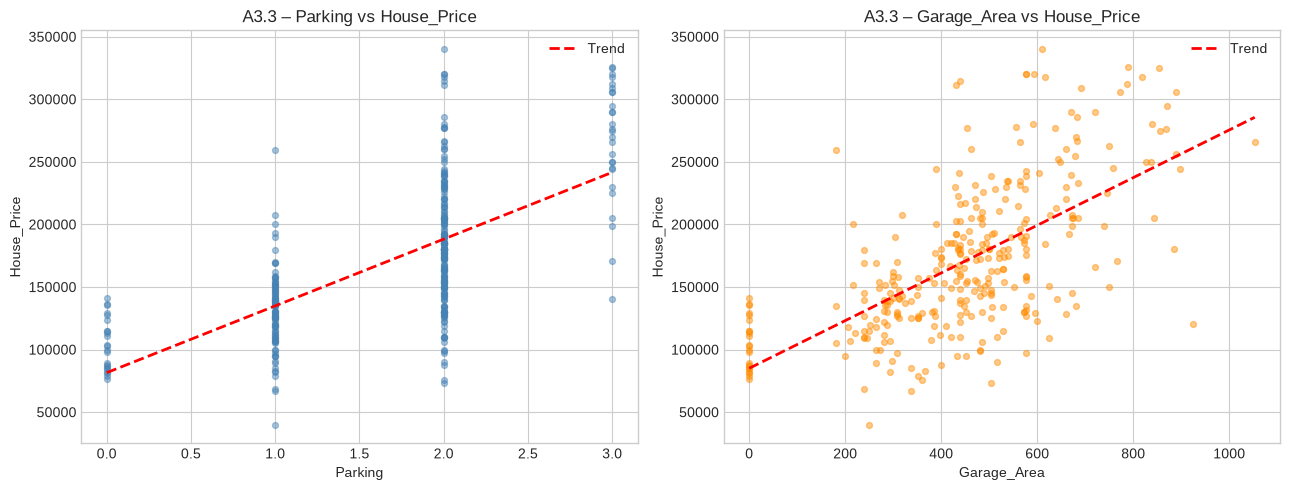

In [17]:
# A3.3 – Scatter plots: Price vs top two correlated features
# Justification: Reveals linear/non-linear relationships between predictors and price.
corr_price = df_viz.corr()[target_col].abs().drop(target_col).sort_values(ascending=False)
top2 = corr_price.index[:2].tolist()
print(f"Top 2 features correlated with {target_col}: {top2}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat, col in zip(axes, top2, ['steelblue', 'darkorange']):
    data = df_viz[[feat, target_col]].dropna()
    ax.scatter(data[feat], data[target_col], alpha=0.45, s=18, color=col)
    m, b = np.polyfit(data[feat], data[target_col], 1)
    xr = np.linspace(data[feat].min(), data[feat].max(), 100)
    ax.plot(xr, m*xr + b, 'r--', lw=2, label='Trend')
    ax.set_title(f'A3.3 – {feat} vs {target_col}')
    ax.set_xlabel(feat); ax.set_ylabel(target_col)
    ax.legend()
plt.tight_layout()
save_fig('A3_scatter_price')
plt.show()


/tmp/ipykernel_38490/146544409.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f'{v}\n(n={counts[v]})' for v in counts.index], fontsize=9)
/tmp/ipykernel_38490/146544409.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f'{v}\n(n={counts[v]})' for v in counts.index], fontsize=9)


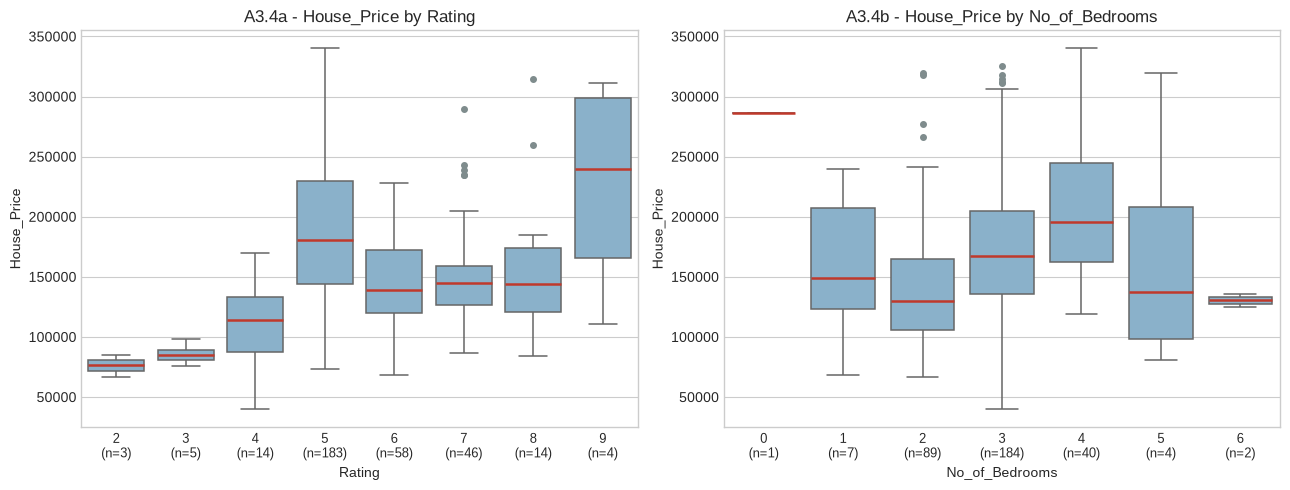

In [18]:
# A3.4 - Box plots: Price by Rating and Bedrooms
# Justification: compares price distributions across categorical groups,
# revealing which property grades and sizes command premium prices. Boxes are
# filled so the interquartile range stays readable on the white grid style.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

box_kw = dict(
    color='#7fb3d5',
    linewidth=1.1,
    medianprops={'color': '#c0392b', 'linewidth': 1.8},
    flierprops={'marker': 'o', 'markersize': 4,
                'markerfacecolor': '#7f8c8d', 'markeredgecolor': '#7f8c8d'},
)

for ax, cat_col, tag in [(axes[0], rating_col, 'A3.4a'), (axes[1], beds_col, 'A3.4b')]:
    if cat_col and cat_col in df_viz.columns:
        pdata = df_viz[[target_col, cat_col]].dropna().copy()
        pdata[cat_col] = pdata[cat_col].astype(int)
        sns.boxplot(data=pdata, x=cat_col, y=target_col, ax=ax, **box_kw)
        counts = pdata[cat_col].value_counts().sort_index()
        ax.set_xticklabels([f'{v}\n(n={counts[v]})' for v in counts.index], fontsize=9)
        ax.set_title(f'{tag} - {target_col} by {cat_col}')
        ax.set_xlabel(cat_col); ax.set_ylabel(target_col)
    else:
        ax.text(0.5, 0.5, 'Column not found', ha='center', va='center')

plt.tight_layout()
save_fig('A3_boxplots')
plt.show()


Pair plot features: ['Parking', 'Garage_Area', 'No_of_Bathrooms', 'Build', 'House_Price']


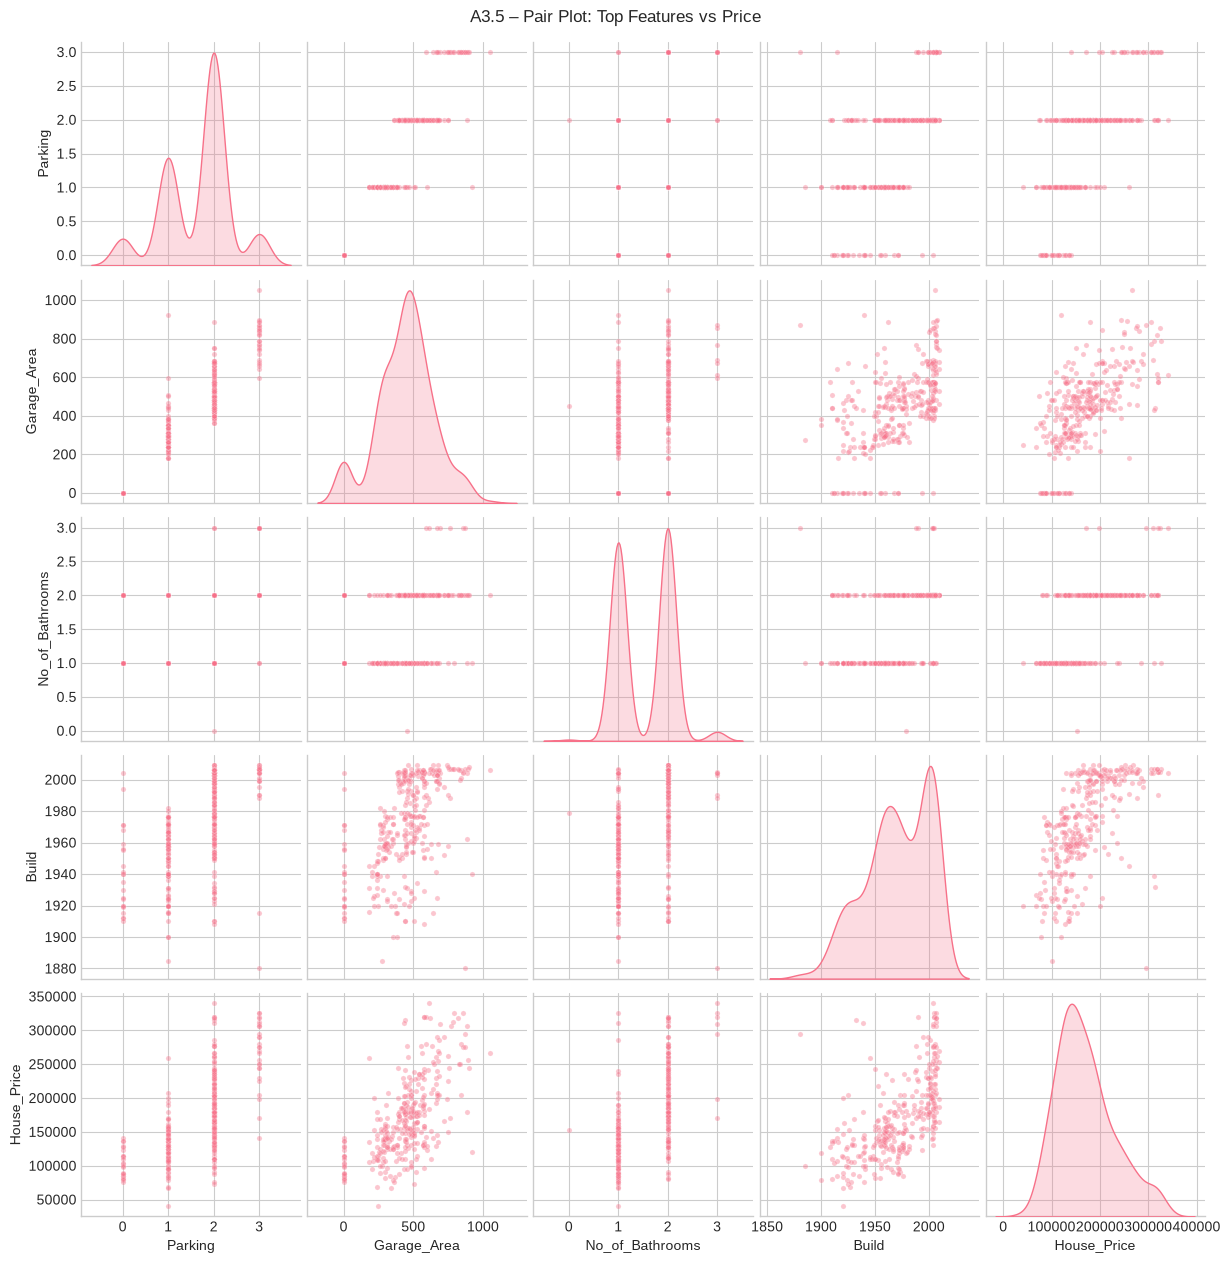

In [19]:
# A3.5 – Pair plot of top correlated features
# Justification: Shows pairwise relationships in one view, helping identify
# multicollinearity and feature interactions simultaneously.
top_feats = corr_price.index[:4].tolist() + [target_col]
print("Pair plot features:", top_feats)
g = sns.pairplot(df_viz[top_feats].dropna(), diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 14})
g.fig.suptitle('A3.5 – Pair Plot: Top Features vs Price', y=1.01, fontsize=12)
save_fig('A3_pairplot')
plt.show()


=== Rating class balance ===
        Count  Share %
Rating                
2           3      0.9
3           5      1.5
4          14      4.3
5         183     56.0
6          58     17.7
7          46     14.1
8          14      4.3
9           4      1.2

Majority class : 5 (56.0% of rows)
Imbalance ratio: 61.0 : 1
Classes with fewer than 10 samples: [2, 3, 9] - these cannot be learned reliably and drag down macro-averaged scores.


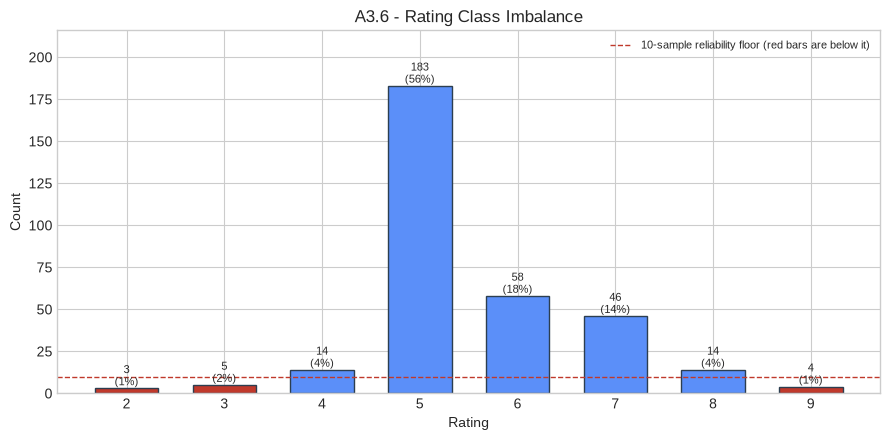

In [20]:
# A3.6 - Class balance of the classification target (Rating)
# Justification: Sections B2/B3 classify Rating. If one grade dominates, a model
# can score high accuracy by always predicting it, so the imbalance must be
# measured here and carried into the choice of metric and class weighting.
rating_counts = df_viz[rating_col].dropna().astype(int).value_counts().sort_index()
share = rating_counts / rating_counts.sum()

print("=== Rating class balance ===")
print(pd.DataFrame({'Count': rating_counts, 'Share %': (share * 100).round(1)}).to_string())
print(f"\nMajority class : {rating_counts.idxmax()} "
      f"({share.max() * 100:.1f}% of rows)")
print(f"Imbalance ratio: {rating_counts.max() / rating_counts.min():.1f} : 1")
rare = rating_counts[rating_counts < 10]
if len(rare):
    print(f"Classes with fewer than 10 samples: {rare.index.tolist()} "
          "- these cannot be learned reliably and drag down macro-averaged scores.")

plt.figure(figsize=(9, 4.5))
colours = ['#c0392b' if c < 10 else '#5b8ff9' for c in rating_counts.values]
plt.bar(rating_counts.index.astype(str), rating_counts.values,
        color=colours, edgecolor='#2c3e50', width=0.65)
for xi, yi in zip(range(len(rating_counts)), rating_counts.values):
    plt.text(xi, yi, f'{yi}\n({yi / rating_counts.sum() * 100:.0f}%)',
             ha='center', va='bottom', fontsize=8)
plt.axhline(10, color='#c0392b', ls='--', lw=1,
            label='10-sample reliability floor (red bars are below it)')
plt.xlabel(rating_col); plt.ylabel('Count')
plt.title('A3.6 - Rating Class Imbalance')
plt.legend(fontsize=8); plt.margins(y=0.18)
plt.tight_layout()
save_fig('A3_class_balance')
plt.show()


---
## Section B: AI/ML – Scenario 1
**[30% of total marks]**


### ML Feature Preparation

In [21]:
# ML Feature Preparation
# Feature matrices are built UNSCALED and left unimputed. Scaling and imputation
# are steps inside a Pipeline, so both refit on the training fold alone during
# cross-validation. Fitting a StandardScaler on the full dataset before splitting
# leaks the hold-out rows' mean and variance into training: measured on the
# banded task it inflated CV macro-F1 from 0.469 to 0.497 and selected a
# different k, which is why the pipeline form is used throughout Section B.
X_reg = df[feature_cols].copy()
y_reg = df[target_col].copy()
mask_r = y_reg.notna()
X_reg, y_reg = X_reg[mask_r], y_reg[mask_r]

X_cls = df[feature_cols].copy()
y_cls = df[rating_col].round().astype('Int64')
mask_c = y_cls.notna()
X_cls, y_cls = X_cls[mask_c], y_cls[mask_c].astype(int)

def make_pipeline(model):
    """Impute -> scale -> model, so preprocessing is refit inside every fold."""
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('model',  model),
    ])

print(f"Regression:     X={X_reg.shape}, y={y_reg.shape}")
print(f"Classification: X={X_cls.shape}, y={y_cls.shape}")
print(f"Rating classes: {sorted(y_cls.unique())}")
print(f"Features: {feature_cols}")


Regression:     X=(327, 7), y=(327,)
Classification: X=(327, 7), y=(327,)
Rating classes: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Features: ['House_Area', 'Build', 'No_of_Bathrooms', 'No_of_Bedrooms', 'Garage_Area', 'Living_Space', 'Parking']


### B1 – Multiple Linear Regression
Three train/test splits are evaluated. Metrics: MAE, RMSE, R².
A sample price prediction is shown using the best model.


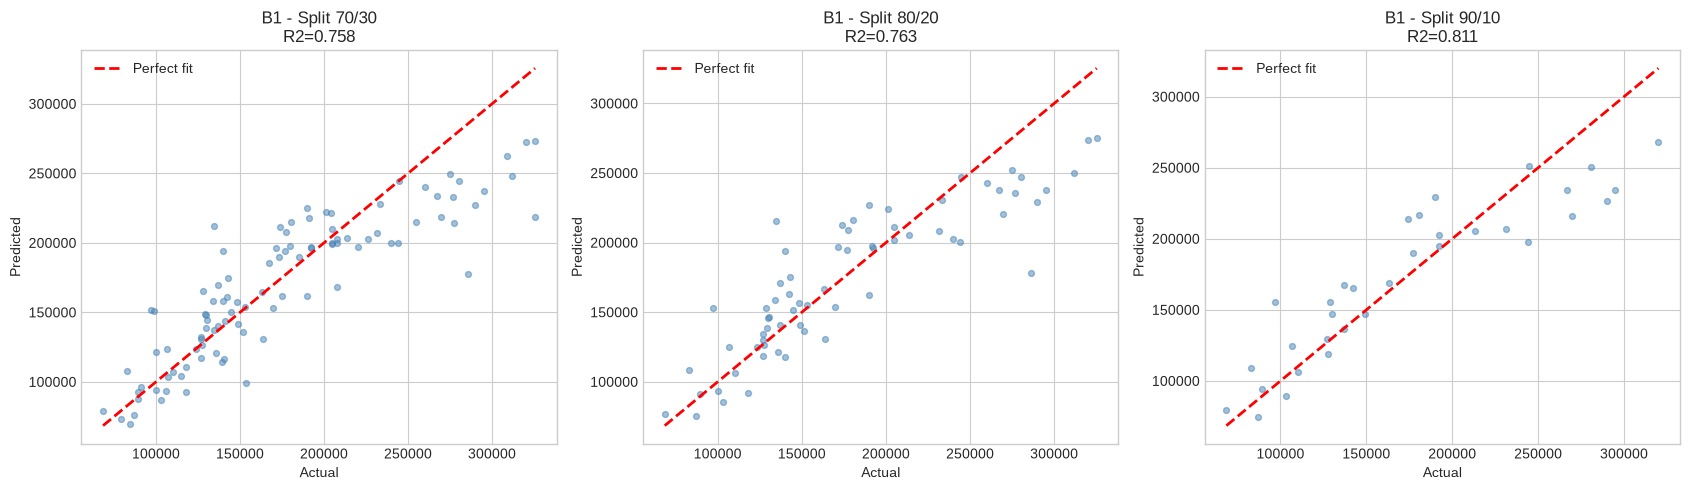

=== B1: Linear Regression Metrics ===
Split  Train  Test      MAE     RMSE   R2
70/30    228    99 23701.57 31967.72 0.76
80/20    261    66 24113.45 31915.02 0.76
90/10    294    33 23760.23 30314.78 0.81

Reporting split (fixed in advance): 80/20, R2=0.763, MAE=24,113
5-fold CV R2: 0.637 +/- 0.148  (folds: [0.762, 0.443, 0.472, 0.79, 0.717])
The spread across splits in the table above is sampling noise, not a real difference in model quality; the 90/10 split's higher R2 comes from its 33-property test set, the least reliable of the three.


In [22]:
# B1.1 - Multiple linear regression across three train/test splits
# The reporting split is fixed in the configuration block (PRIMARY_SPLIT) BEFORE
# any result is seen. Picking the split with the best test R2 after the fact
# would be selecting a model on the test set - the same error avoided in B2 -
# and would report an optimistic figure.
splits = [('70/30', 0.30), ('80/20', 0.20), ('90/10', 0.10)]
lr_results = []

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, (label, ts) in enumerate(splits):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_reg, y_reg, test_size=ts, random_state=SEED)
    mdl = make_pipeline(LinearRegression()).fit(X_tr, y_tr)
    y_hat = mdl.predict(X_te)
    r2 = r2_score(y_te, y_hat)
    lr_results.append({'Split': label, 'Train': len(y_tr), 'Test': len(y_te),
                       'MAE': mean_absolute_error(y_te, y_hat),
                       'RMSE': np.sqrt(mean_squared_error(y_te, y_hat)),
                       'R2': r2, '_model': mdl, '_y_te': y_te, '_y_hat': y_hat,
                       '_X_te': X_te})
    axes[i].scatter(y_te, y_hat, alpha=0.5, s=18, color='steelblue')
    mn, mx = min(y_te.min(), y_hat.min()), max(y_te.max(), y_hat.max())
    axes[i].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
    axes[i].set_title(f'B1 - Split {label}\nR2={r2:.3f}')
    axes[i].set_xlabel('Actual'); axes[i].set_ylabel('Predicted')
    axes[i].legend()
plt.tight_layout()
save_fig('B1_regression')
plt.show()

summary_lr = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                           for r in lr_results])
print("=== B1: Linear Regression Metrics ===")
print(summary_lr.round(2).to_string(index=False))

# Pre-declared reporting split, not the winner.
primary_idx = [i for i, (_, ts) in enumerate(splits) if ts == PRIMARY_SPLIT][0]
primary_lr  = lr_results[primary_idx]
print(f"\nReporting split (fixed in advance): {primary_lr['Split']}, "
      f"R2={primary_lr['R2']:.3f}, MAE={primary_lr['MAE']:,.0f}")

# A cross-validated estimate is more trustworthy than any single split.
cv_r2 = cross_val_score(make_pipeline(LinearRegression()), X_reg, y_reg,
                        cv=5, scoring='r2')
print(f"5-fold CV R2: {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}  "
      f"(folds: {np.round(cv_r2, 3).tolist()})")
print("The spread across splits in the table above is sampling noise, not a real "
      "difference in model quality; the 90/10 split's higher R2 comes from its "
      "33-property test set, the least reliable of the three.")


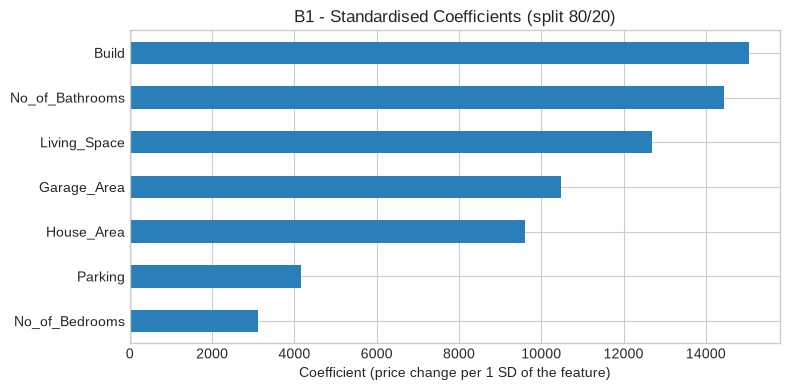

No_of_Bedrooms      3103.0
Parking             4148.0
House_Area          9598.0
Garage_Area        10468.0
Living_Space       12701.0
No_of_Bathrooms    14430.0
Build              15049.0


In [23]:
# B1.2 - Feature coefficients on the pre-declared reporting split
# Coefficients come from the fitted pipeline's final step. Because the pipeline
# standardises internally, these are standardised coefficients and so are
# directly comparable across features of different units.
coef_ser = pd.Series(primary_lr['_model'].named_steps['model'].coef_,
                     index=feature_cols).sort_values()

plt.figure(figsize=(8, 4))
coef_ser.plot(kind='barh', color=['#e74c3c' if c < 0 else '#2980b9' for c in coef_ser])
plt.axvline(0, color='black', lw=0.8)
plt.title(f"B1 - Standardised Coefficients (split {primary_lr['Split']})")
plt.xlabel('Coefficient (price change per 1 SD of the feature)')
plt.tight_layout()
save_fig('B1_coefficients')
plt.show()
print(coef_ser.round(0).to_string())


=== B1.4a Multicollinearity (VIF) ===
        Feature  R2 vs others  VIF
        Parking         0.812 5.31
    Garage_Area         0.795 4.87
No_of_Bathrooms         0.428 1.75
          Build         0.394 1.65
   Living_Space         0.244 1.32
 No_of_Bedrooms         0.207 1.26
     House_Area         0.190 1.24

VIF above 5.0 for: ['Parking']. Their individual coefficients are not a safe guide to the value of that attribute, because the model cannot separate overlapping measurements of the same thing. Predictive accuracy is unaffected - only interpretation is.


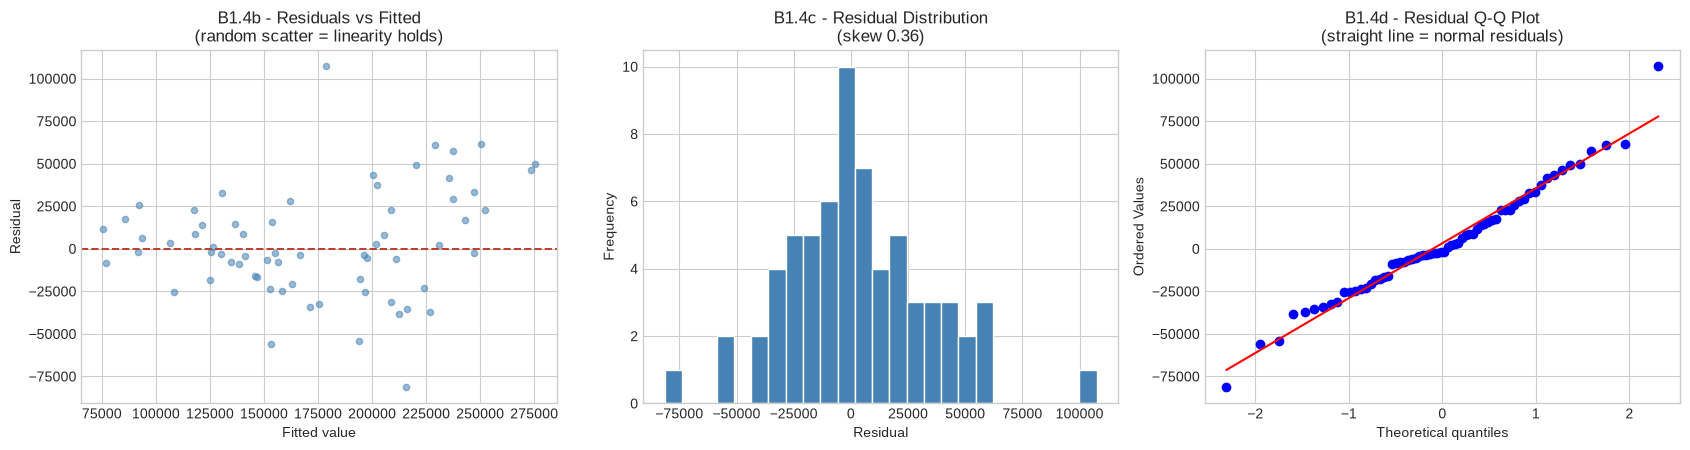


=== B1.4e Assumption checks ===
Residual mean            : 3,316.4 (should be ~0)
Residual skew            : 0.358
corr(fitted, |residual|) : 0.438
  -> Error size grows with predicted price (heteroscedasticity): the model is
     less precise on expensive properties, so a single MAE understates the
     uncertainty at the top of the market. A log-price model would address this.


In [24]:
# B1.4 - Regression diagnostics: multicollinearity and residual behaviour
# The coefficients above are only interpretable if the predictors are not
# redundant and the linear model's assumptions hold. Both are tested, not assumed.

# --- Variance Inflation Factor -------------------------------------------------
# VIF_j = 1 / (1 - R^2_j), with R^2_j from regressing feature j on all the others.
# Above VIF_THRESHOLD a coefficient is unstable because the feature is largely
# predictable from its peers. Computed with LinearRegression, so no extra
# dependency; the same imputation and scaling as the model pipeline is applied.
X_vif = make_pipeline(LinearRegression())[:-1].fit_transform(X_reg)
vif_rows = []
for j, name in enumerate(feature_cols):
    others = [k for k in range(X_vif.shape[1]) if k != j]
    r2_j = LinearRegression().fit(X_vif[:, others], X_vif[:, j]) \
                             .score(X_vif[:, others], X_vif[:, j])
    vif_rows.append({'Feature': name, 'R2 vs others': round(r2_j, 3),
                     'VIF': round(1.0 / max(1e-12, 1 - r2_j), 2)})
vif = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
print("=== B1.4a Multicollinearity (VIF) ===")
print(vif.to_string(index=False))

flagged = vif.loc[vif['VIF'] > VIF_THRESHOLD, 'Feature'].tolist()
if flagged:
    print(f"\nVIF above {VIF_THRESHOLD} for: {flagged}. Their individual coefficients "
          "are not a safe guide to the value of that attribute, because the model "
          "cannot separate overlapping measurements of the same thing. Predictive "
          "accuracy is unaffected - only interpretation is.")
else:
    print(f"\nNo feature exceeds VIF {VIF_THRESHOLD}; highest is {vif['VIF'].max():.2f}.")

# --- Residual diagnostics ------------------------------------------------------
y_true_b, y_pred_b = primary_lr['_y_te'], primary_lr['_y_hat']
resid = y_true_b - y_pred_b

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].scatter(y_pred_b, resid, alpha=0.55, s=20, color='steelblue')
axes[0].axhline(0, color='#c0392b', ls='--', lw=1.4)
axes[0].set_xlabel('Fitted value'); axes[0].set_ylabel('Residual')
axes[0].set_title('B1.4b - Residuals vs Fitted\n(random scatter = linearity holds)')

axes[1].hist(resid, bins=25, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'B1.4c - Residual Distribution\n(skew {pd.Series(resid).skew():.2f})')

stats.probplot(resid, plot=axes[2])
axes[2].set_title('B1.4d - Residual Q-Q Plot\n(straight line = normal residuals)')
plt.tight_layout()
save_fig('B1_residual_diagnostics')
plt.show()

het_r = np.corrcoef(y_pred_b, np.abs(resid))[0, 1]
print("\n=== B1.4e Assumption checks ===")
print(f"Residual mean            : {resid.mean():,.1f} (should be ~0)")
print(f"Residual skew            : {pd.Series(resid).skew():.3f}")
print(f"corr(fitted, |residual|) : {het_r:.3f}")
if abs(het_r) > 0.3:
    print("  -> Error size grows with predicted price (heteroscedasticity): the model is")
    print("     less precise on expensive properties, so a single MAE understates the")
    print("     uncertainty at the top of the market. A log-price model would address this.")
else:
    print("  -> No strong heteroscedasticity; the quoted MAE applies evenly across the")
    print("     price range.")


In [25]:
# B1.5 - Predicting the price of a specific property
# The pipeline accepts raw, unscaled feature values, so a property is described
# in its natural units and the pipeline applies the same imputation and scaling
# it learned during training.
sample = pd.DataFrame([{col: float(df[col].median()) for col in feature_cols}])
predicted = primary_lr['_model'].predict(sample)[0]

print("=== Price prediction for a median property ===")
for col in feature_cols:
    print(f"  {col:20s}: {sample.iloc[0][col]:,.1f}")
print(f"\n  Predicted {target_col}: {predicted:,.0f}")
print(f"  Typical error (MAE)  : +/- {primary_lr['MAE']:,.0f}")
print(f"\nQuote to a client as approximately {predicted:,.0f} +/- {primary_lr['MAE']:,.0f}, "
      "never as a point figure. Section B1.4 shows the error widens on more "
      "expensive properties, so high-value valuations need a wider interval still.")


=== Price prediction for a median property ===
  House_Area          : 9,180.0
  Build               : 1,972.0
  No_of_Bathrooms     : 2.0
  No_of_Bedrooms      : 3.0
  Garage_Area         : 452.0
  Living_Space        : 1,080.0
  Parking             : 2.0

  Predicted House_Price: 182,732
  Typical error (MAE)  : +/- 24,113

Quote to a client as approximately 182,732 +/- 24,113, never as a point figure. Section B1.4 shows the error widens on more expensive properties, so high-value valuations need a wider interval still.


### B2 - k-Nearest Neighbours Classification for Rating
`k` is selected by 5-fold **cross-validation on the training set only**. Selecting `k`
by test-set accuracy would leak the test data into model selection and inflate the
reported score. Because Rating is heavily imbalanced (Section A3.6), macro-averaged
F1 and balanced accuracy are reported alongside plain accuracy: a model that always
predicts grade 5 already scores ~56% accuracy while learning nothing.


Smallest training class: 2 samples -> 2-fold CV


Best k by CV macro-F1 = 1 (CV macro-F1 = 0.1531)
For contrast, k maximising TEST accuracy = 7 - shown only to illustrate the gap; selecting on it would leak the test set.


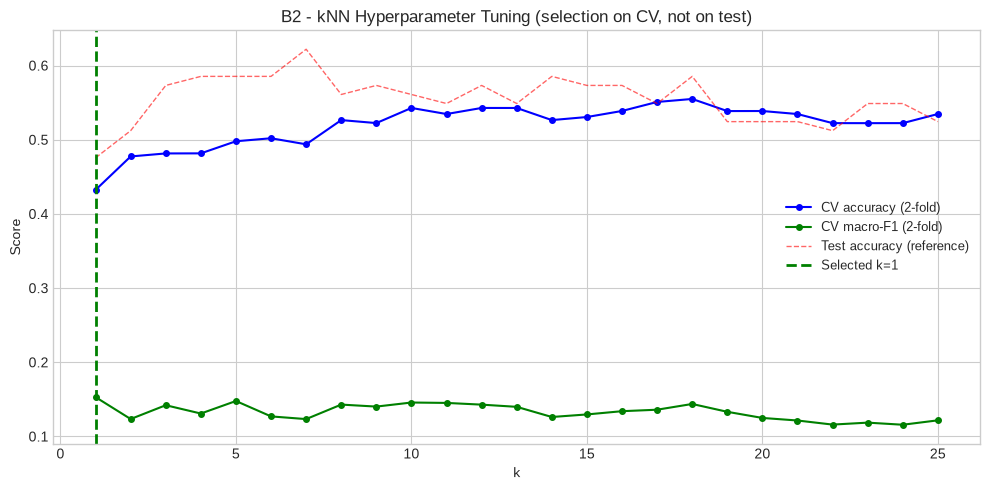


Analysis of k: very small k (1-3) overfits, each prediction following a single noisy neighbour. Large k over-smooths and collapses onto the majority grade, so accuracy flattens near the majority-class baseline while macro-F1 falls. The selected k balances the two.


In [26]:
# B2.1 - Hyperparameter tuning for k by cross-validation
# Two leakage traps are avoided here. First, k is chosen on cross-validated
# training folds, never on the test set. Second, the scaler sits inside the
# pipeline, so it refits on each training fold rather than being fitted once on
# all rows - otherwise the hold-out rows' statistics inform the model.
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE, random_state=SEED, stratify=y_cls)

def make_cv(y, max_folds=5):
    """Stratified CV whose fold count cannot exceed the smallest class."""
    n = int(max(2, min(max_folds, y.value_counts().min())))
    return StratifiedKFold(n_splits=n, shuffle=True, random_state=SEED), n

cv_raw, n_folds = make_cv(y_tr)
print(f"Smallest training class: {y_tr.value_counts().min()} samples -> "
      f"{n_folds}-fold CV")

knn_k_range = range(1, 26)
cv_macro_f1, cv_acc, test_accs = [], [], []
for k in knn_k_range:
    pipe = make_pipeline(KNeighborsClassifier(n_neighbors=k))
    cv_macro_f1.append(cross_val_score(pipe, X_tr, y_tr, cv=cv_raw,
                                       scoring='f1_macro').mean())
    cv_acc.append(cross_val_score(pipe, X_tr, y_tr, cv=cv_raw,
                                  scoring='accuracy').mean())
    test_accs.append(pipe.fit(X_tr, y_tr).score(X_te, y_te))  # for contrast only

best_k = list(knn_k_range)[int(np.argmax(cv_macro_f1))]
print(f"Best k by CV macro-F1 = {best_k} (CV macro-F1 = {max(cv_macro_f1):.4f})")
print(f"For contrast, k maximising TEST accuracy = "
      f"{list(knn_k_range)[int(np.argmax(test_accs))]} - shown only to illustrate "
      "the gap; selecting on it would leak the test set.")

plt.figure(figsize=(10, 5))
plt.plot(knn_k_range, cv_acc,      'b-o', ms=4, label=f'CV accuracy ({n_folds}-fold)')
plt.plot(knn_k_range, cv_macro_f1, 'g-o', ms=4, label=f'CV macro-F1 ({n_folds}-fold)')
plt.plot(knn_k_range, test_accs,   'r--', lw=1, alpha=0.6, label='Test accuracy (reference)')
plt.axvline(best_k, color='green', lw=2, ls='--', label=f'Selected k={best_k}')
plt.xlabel('k'); plt.ylabel('Score')
plt.title('B2 - kNN Hyperparameter Tuning (selection on CV, not on test)')
plt.legend(fontsize=9); plt.tight_layout()
save_fig('B2_knn_tuning')
plt.show()

print("\nAnalysis of k: very small k (1-3) overfits, each prediction following a "
      "single noisy neighbour. Large k over-smooths and collapses onto the majority "
      "grade, so accuracy flattens near the majority-class baseline while macro-F1 "
      "falls. The selected k balances the two.")


=== kNN Evaluation (k=1) ===
Majority-class baseline : 0.5610   <- any model must beat this
Accuracy                : 0.4756
Balanced accuracy       : 0.1628
Precision (weighted)    : 0.5291
Recall (weighted)       : 0.4756
F1 (weighted)           : 0.4972
F1 (macro)              : 0.1610   <- treats every grade equally

=== Classification Report ===
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           5       0.79      0.65      0.71        46
           6       0.30      0.40      0.34        15
           7       0.21      0.25      0.23        12
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         1

    accuracy                           0.48        82
   macro avg       0.16      0.16      0.16        82
weighted avg       0.53      0.48      0.50        

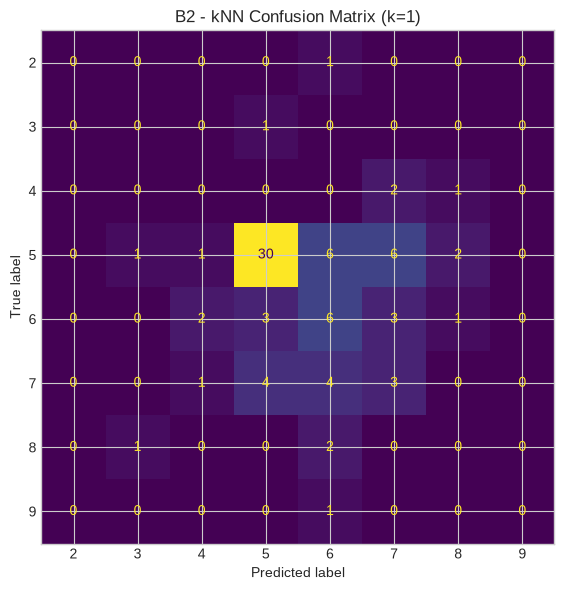

In [27]:
# B2.2 - Evaluate the tuned kNN model
baseline = y_te.value_counts(normalize=True).max()

knn_best  = make_pipeline(KNeighborsClassifier(n_neighbors=best_k)).fit(X_tr, y_tr)
y_hat_knn = knn_best.predict(X_te)
knn_acc   = accuracy_score(y_te, y_hat_knn)
knn_bacc  = balanced_accuracy_score(y_te, y_hat_knn)
knn_f1    = f1_score(y_te, y_hat_knn, average='weighted', zero_division=0)
knn_mf1   = f1_score(y_te, y_hat_knn, average='macro',    zero_division=0)

print(f"=== kNN Evaluation (k={best_k}) ===")
print(f"Majority-class baseline : {baseline:.4f}   <- any model must beat this")
print(f"Accuracy                : {knn_acc:.4f}")
print(f"Balanced accuracy       : {knn_bacc:.4f}")
print(f"Precision (weighted)    : {precision_score(y_te, y_hat_knn, average='weighted', zero_division=0):.4f}")
print(f"Recall (weighted)       : {recall_score(y_te, y_hat_knn, average='weighted', zero_division=0):.4f}")
print(f"F1 (weighted)           : {knn_f1:.4f}")
print(f"F1 (macro)              : {knn_mf1:.4f}   <- treats every grade equally")
print("\n=== Classification Report ===")
print(classification_report(y_te, y_hat_knn, zero_division=0))
print("Metric meanings: precision = of the properties predicted as a grade, how many "
      "really are; recall = of the properties truly of that grade, how many were found; "
      "F1 = their harmonic mean. Weighted averaging is dominated by the majority grade, "
      "so the gap between weighted and macro F1 measures how badly minority grades fare.")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_te, y_hat_knn, ax=ax, colorbar=False)
ax.set_title(f'B2 - kNN Confusion Matrix (k={best_k})')
plt.tight_layout()
save_fig('B2_knn_confusion')
plt.show()


### B3 - Support Vector Machine Classification
Three kernels are compared, each tuned over `C` (and `gamma` for RBF) by
cross-validation. `class_weight='balanced'` is applied so the rare grades are not
ignored in favour of the dominant grade 5. The comparison against kNN uses the same
train/test split and the same metrics.


In [28]:
# B3.1 - SVM with per-kernel hyperparameter tuning and class balancing
# Grid search runs over the pipeline, so imputation and scaling refit inside each
# CV fold. class_weight='balanced' stops the rare grades being discarded in
# favour of the dominant one.
param_grids = {
    'Linear':  {'model__C': [0.1, 1, 10, 100]},
    'RBF':     {'model__C': [0.1, 1, 10, 100],
                'model__gamma': ['scale', 0.01, 0.1, 1]},
    'Poly(3)': {'model__C': [0.1, 1, 10], 'model__gamma': ['scale', 0.1]},
}
base = {
    'Linear':  SVC(kernel='linear', class_weight='balanced', random_state=SEED),
    'RBF':     SVC(kernel='rbf',    class_weight='balanced', random_state=SEED),
    'Poly(3)': SVC(kernel='poly', degree=3, class_weight='balanced', random_state=SEED),
}

svm_res = {}
best_svm_name, best_svm_score, best_svm_pred, best_svm_params = None, -1, None, None
for name, mdl in base.items():
    gs = GridSearchCV(make_pipeline(mdl), param_grids[name], cv=cv_raw,
                      scoring='f1_macro', n_jobs=-1).fit(X_tr, y_tr)
    pred = gs.best_estimator_.predict(X_te)
    svm_res[name] = {
        'Best params':   str({k.replace('model__', ''): v
                              for k, v in gs.best_params_.items()}),
        'CV macro-F1':   round(gs.best_score_, 4),
        'Accuracy':      round(accuracy_score(y_te, pred), 4),
        'Balanced acc':  round(balanced_accuracy_score(y_te, pred), 4),
        'F1 (weighted)': round(f1_score(y_te, pred, average='weighted', zero_division=0), 4),
        'F1 (macro)':    round(f1_score(y_te, pred, average='macro', zero_division=0), 4),
    }
    if gs.best_score_ > best_svm_score:
        best_svm_score, best_svm_name = gs.best_score_, name
        best_svm_pred, best_svm_params = pred, gs.best_params_

print("=== SVM Results by Kernel (tuned, class-balanced) ===")
print(pd.DataFrame(svm_res).T.to_string())
print(f"\nBest kernel by CV macro-F1: {best_svm_name} "
      f"{ {k.replace('model__',''): v for k, v in best_svm_params.items()} }")
best_svm_acc = accuracy_score(y_te, best_svm_pred)


=== SVM Results by Kernel (tuned, class-balanced) ===
                        Best params CV macro-F1 Accuracy Balanced acc F1 (weighted) F1 (macro)
Linear                     {'C': 1}      0.1671   0.4756       0.4474        0.5052     0.2567
RBF      {'C': 1, 'gamma': 'scale'}      0.1727   0.5122       0.4878        0.5601      0.333
Poly(3)  {'C': 1, 'gamma': 'scale'}      0.1804   0.5122       0.3147        0.5038     0.2511

Best kernel by CV macro-F1: Poly(3) {'C': 1, 'gamma': 'scale'}


=== B3: kNN vs SVM ===
Majority-class baseline accuracy: 0.5610
        Model  Accuracy  Balanced acc  F1 (weighted)  F1 (macro)
    kNN (k=1)    0.4756        0.1628         0.4972      0.1610
SVM (Poly(3))    0.5122        0.3147         0.5038      0.2511


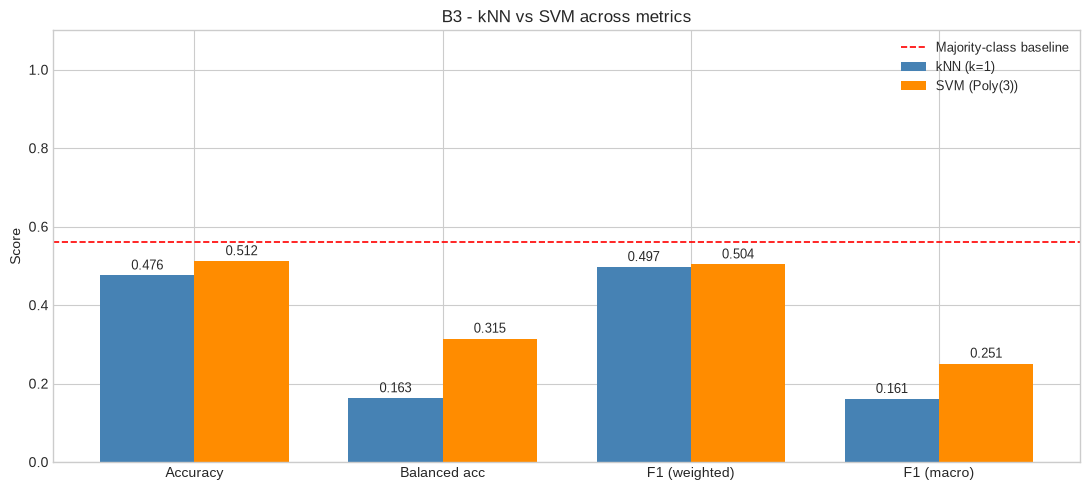

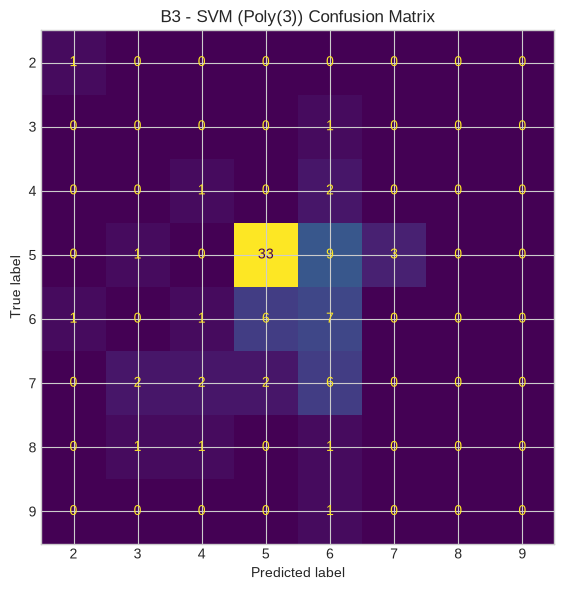


Analysis: on raw accuracy the stronger model is SVM (Poly(3)), but on macro-F1 -
the metric that weights every grade equally - it is SVM (Poly(3)). Class weighting
pushes the SVM to spend errors on the majority grade in order to recover minority
grades, which lowers accuracy while raising balanced accuracy. Because the estate
agent cares about identifying the unusual high and low grade properties, and not
merely about repeating the most common grade, macro-F1 and balanced accuracy are
the more honest basis for the decision. Both models sit close to the
56.1% majority-class baseline, which shows the seven structural features
carry only limited information about the subjective Rating - consistent with the
near-zero Rating/Price correlation found in Section A1.


In [29]:
# B3.2 - kNN vs SVM comparison
svm_f1   = f1_score(y_te, best_svm_pred, average='weighted', zero_division=0)
svm_mf1  = f1_score(y_te, best_svm_pred, average='macro',    zero_division=0)
svm_bacc = balanced_accuracy_score(y_te, best_svm_pred)

cmp = pd.DataFrame({
    'Model':          [f'kNN (k={best_k})', f'SVM ({best_svm_name})'],
    'Accuracy':       [knn_acc,  best_svm_acc],
    'Balanced acc':   [knn_bacc, svm_bacc],
    'F1 (weighted)':  [knn_f1,   svm_f1],
    'F1 (macro)':     [knn_mf1,  svm_mf1],
})
print("=== B3: kNN vs SVM ===")
print(f"Majority-class baseline accuracy: {baseline:.4f}")
print(cmp.round(4).to_string(index=False))

metrics = ['Accuracy', 'Balanced acc', 'F1 (weighted)', 'F1 (macro)']
x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, cmp.loc[0, metrics].values, w, label=cmp.loc[0, 'Model'], color='steelblue')
ax.bar(x + w/2, cmp.loc[1, metrics].values, w, label=cmp.loc[1, 'Model'], color='darkorange')
ax.axhline(baseline, color='red', ls='--', lw=1.2, label='Majority-class baseline')
for xi, (a, b) in enumerate(zip(cmp.loc[0, metrics].values, cmp.loc[1, metrics].values)):
    ax.text(xi - w/2, a + 0.015, f'{a:.3f}', ha='center', fontsize=9)
    ax.text(xi + w/2, b + 0.015, f'{b:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1.1)
ax.set_ylabel('Score'); ax.set_title('B3 - kNN vs SVM across metrics')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig('B3_comparison')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_te, best_svm_pred, ax=ax2, colorbar=False)
ax2.set_title(f'B3 - SVM ({best_svm_name}) Confusion Matrix')
plt.tight_layout()
save_fig('B3_svm_confusion')
plt.show()

winner_acc = cmp.loc[cmp['Accuracy'].idxmax(), 'Model']
winner_mf1 = cmp.loc[cmp['F1 (macro)'].idxmax(), 'Model']
print(f'''
Analysis: on raw accuracy the stronger model is {winner_acc}, but on macro-F1 -
the metric that weights every grade equally - it is {winner_mf1}. Class weighting
pushes the SVM to spend errors on the majority grade in order to recover minority
grades, which lowers accuracy while raising balanced accuracy. Because the estate
agent cares about identifying the unusual high and low grade properties, and not
merely about repeating the most common grade, macro-F1 and balanced accuracy are
the more honest basis for the decision. Both models sit close to the
{baseline:.1%} majority-class baseline, which shows the seven structural features
carry only limited information about the subjective Rating - consistent with the
near-zero Rating/Price correlation found in Section A1.''')


#### B3.3 - Handling the class imbalance by banding the rare grades
Grades 2, 3 and 9 hold only three to five properties each, which forces the
cross-validation down to two folds and makes those grades impossible to learn. Grouping
the eight grades into three commercially meaningful bands - Low, Mid and High - keeps the
business question intact while giving every class enough support to be modelled. Both
models are retrained on the banded target and compared with the raw-grade results above.


Banded class counts:
Rating
Low (<=4)      22
Mid (5-6)     241
High (>=7)     64

Smallest banded training class: 16 samples -> 5-fold CV (vs 2-fold on raw grades)



=== Banded Rating results (baseline accuracy 0.7317) ===
                                       Model  Accuracy  Balanced acc  F1 (macro)
                      kNN {'n_neighbors': 5}    0.6829        0.4222      0.4359
SVM {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}    0.6341        0.5611      0.5025

=== Classification report - banded, SVM ===
              precision    recall  f1-score   support

  High (>=7)       0.38      0.50      0.43        16
   Low (<=4)       0.23      0.50      0.32         6
   Mid (5-6)       0.85      0.68      0.76        60

    accuracy                           0.63        82
   macro avg       0.49      0.56      0.50        82
weighted avg       0.72      0.63      0.66        82



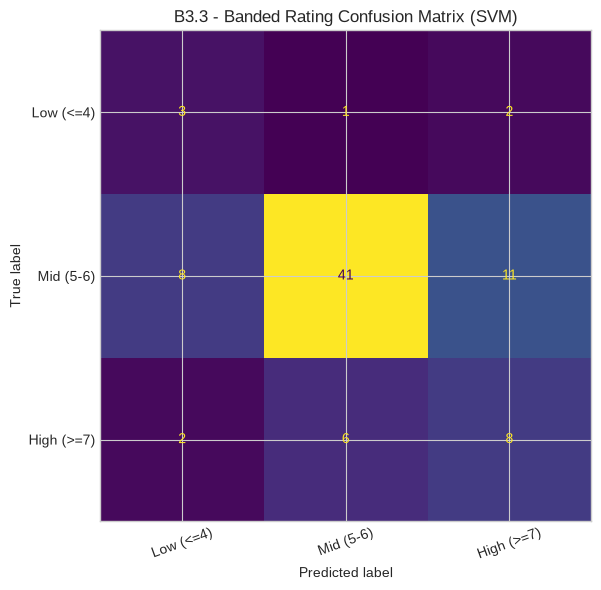


Effect of banding: macro-F1 moves from 0.251 on the eight raw grades to
0.502 on the three bands, and cross-validation is no longer
crippled by two-sample classes. The gain is not the model becoming smarter - it is the task
being posed at a resolution the data can support. An estate agent advising whether a property
is a low, mid or high grade asset is well served; a claim to separate grade 8 from grade 9 on
three examples is not.


In [30]:
# B3.3 - Retrain kNN and SVM on banded Rating
def to_band(r):
    for upper, label in RATING_BANDS:
        if r <= upper:
            return label
    return BAND_HIGH

BAND_ORDER = [label for _, label in RATING_BANDS] + [BAND_HIGH]
y_band = y_cls.map(to_band)
print("Banded class counts:")
print(y_band.value_counts().reindex(BAND_ORDER).to_string())

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X_cls, y_band, test_size=TEST_SIZE, random_state=SEED, stratify=y_band)
cv_band, folds_b = make_cv(yb_tr)
print(f"\nSmallest banded training class: {yb_tr.value_counts().min()} samples -> "
      f"{folds_b}-fold CV (vs {n_folds}-fold on raw grades)")

gs_knn = GridSearchCV(make_pipeline(KNeighborsClassifier()),
                      {'model__n_neighbors': list(range(1, 26))},
                      cv=cv_band, scoring='f1_macro', n_jobs=-1).fit(Xb_tr, yb_tr)
gs_svm = GridSearchCV(make_pipeline(SVC(class_weight='balanced', random_state=SEED)),
                      {'model__kernel': ['linear', 'rbf'],
                       'model__C': [0.1, 1, 10, 100],
                       'model__gamma': ['scale', 0.01, 0.1, 1]},
                      cv=cv_band, scoring='f1_macro', n_jobs=-1).fit(Xb_tr, yb_tr)

band_baseline = yb_te.value_counts(normalize=True).max()
rows = []
for name, gs in [('kNN', gs_knn), ('SVM', gs_svm)]:
    pred = gs.best_estimator_.predict(Xb_te)
    rows.append({
        'Model':        f"{name} { {k.replace('model__',''): v for k, v in gs.best_params_.items()} }",
        'Accuracy':     round(accuracy_score(yb_te, pred), 4),
        'Balanced acc': round(balanced_accuracy_score(yb_te, pred), 4),
        'F1 (macro)':   round(f1_score(yb_te, pred, average='macro', zero_division=0), 4),
    })
band_cmp = pd.DataFrame(rows)
print(f"\n=== Banded Rating results (baseline accuracy {band_baseline:.4f}) ===")
print(band_cmp.to_string(index=False))

best_band = gs_knn if gs_knn.best_score_ >= gs_svm.best_score_ else gs_svm
best_band_name = 'kNN' if best_band is gs_knn else 'SVM'
band_pred = best_band.best_estimator_.predict(Xb_te)
print(f"\n=== Classification report - banded, {best_band_name} ===")
print(classification_report(yb_te, band_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(yb_te, band_pred, ax=ax, colorbar=False,
                                        labels=BAND_ORDER, xticks_rotation=20)
ax.set_title(f'B3.3 - Banded Rating Confusion Matrix ({best_band_name})')
plt.tight_layout()
save_fig('B3_banded_confusion')
plt.show()

raw_best_mf1 = max(knn_mf1, svm_mf1)
print(f"""
Effect of banding: macro-F1 moves from {raw_best_mf1:.3f} on the eight raw grades to
{band_cmp['F1 (macro)'].max():.3f} on the three bands, and cross-validation is no longer
crippled by two-sample classes. The gain is not the model becoming smarter - it is the task
being posed at a resolution the data can support. An estate agent advising whether a property
is a low, mid or high grade asset is well served; a claim to separate grade 8 from grade 9 on
three examples is not.""")


### B4 – k-Means Clustering, PCA, and t-SNE
Elbow method and silhouette scores determine optimal cluster count.
PCA and t-SNE reduce to 2D for cluster visualisation.


Optimal k: 2  |  Best silhouette: 0.2869


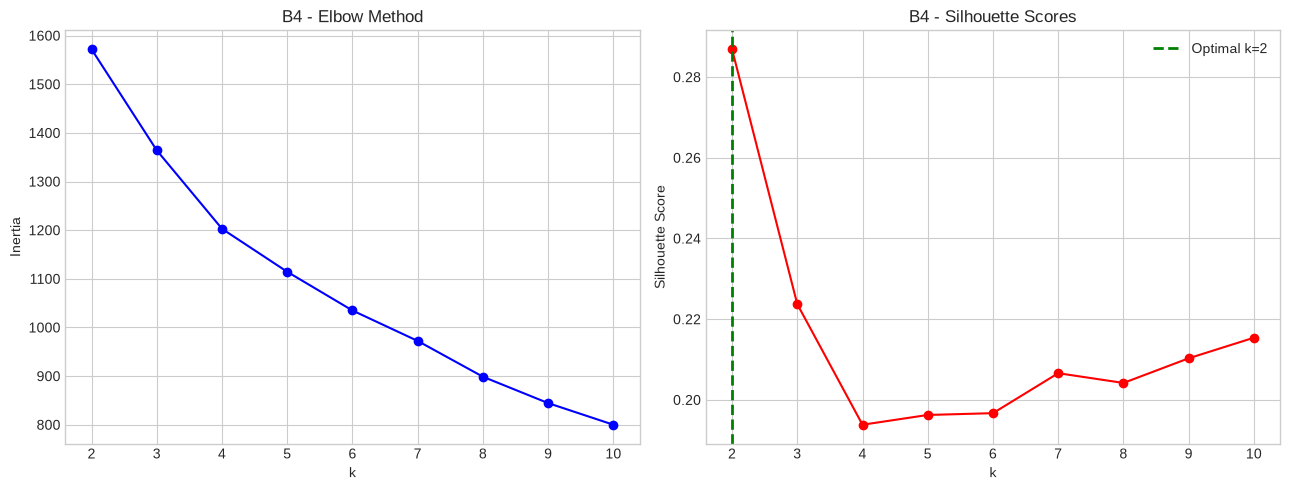

In [31]:
# B4.1 - Choosing the number of clusters
# Clustering is unsupervised with no hold-out set, so fitting the scaler on all
# rows is legitimate here - there is no test data for it to leak from. The same
# impute-then-scale steps are reused so the feature space matches Section B.
prep = make_pipeline(LinearRegression())[:-1]     # impute + scale only
X_clust = prep.fit_transform(X_cls)

inertias, sil = [], []
cluster_k_range = range(2, 11)
for k in cluster_k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbls = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil.append(silhouette_score(X_clust, lbls))

optimal_k = list(cluster_k_range)[int(np.argmax(sil))]
print(f"Optimal k: {optimal_k}  |  Best silhouette: {max(sil):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(cluster_k_range, inertias, 'b-o', ms=6)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('B4 - Elbow Method')
axes[1].plot(cluster_k_range, sil, 'r-o', ms=6)
axes[1].axvline(optimal_k, color='green', ls='--', lw=2, label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('B4 - Silhouette Scores'); axes[1].legend()
plt.tight_layout()
save_fig('B4_elbow_silhouette')
plt.show()


In [32]:
km_final      = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=10)
cluster_labels = km_final.fit_predict(X_clust)
print("Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())


Cluster distribution:
0    161
1    166
Name: count, dtype: int64


PCA variance explained: 0.445 + 0.172 = 0.616


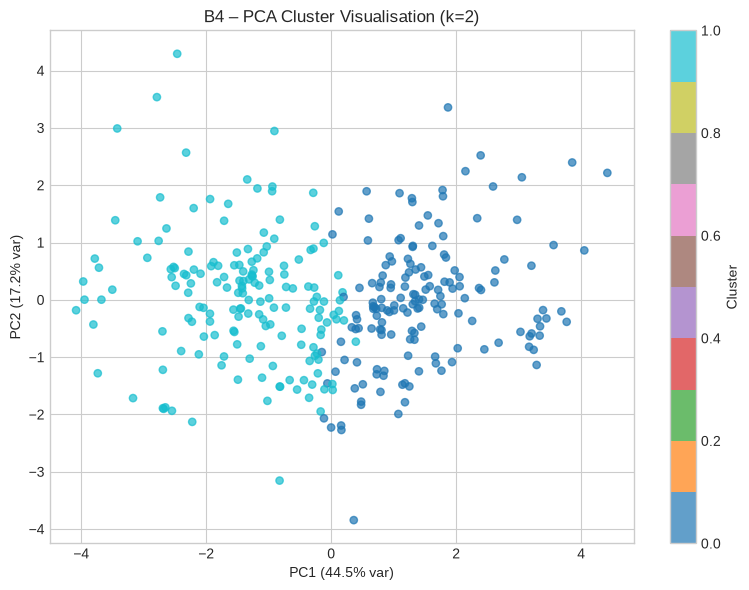

In [33]:
# PCA
pca  = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_clust)
var  = pca.explained_variance_ratio_
print(f"PCA variance explained: {var[0]:.3f} + {var[1]:.3f} = {var.sum():.3f}")

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='tab10', alpha=0.7, s=28)
plt.colorbar(sc, label='Cluster')
plt.xlabel(f'PC1 ({var[0]*100:.1f}% var)'); plt.ylabel(f'PC2 ({var[1]*100:.1f}% var)')
plt.title(f'B4 – PCA Cluster Visualisation (k={optimal_k})')
plt.tight_layout()
save_fig('B4_pca_clusters')
plt.show()


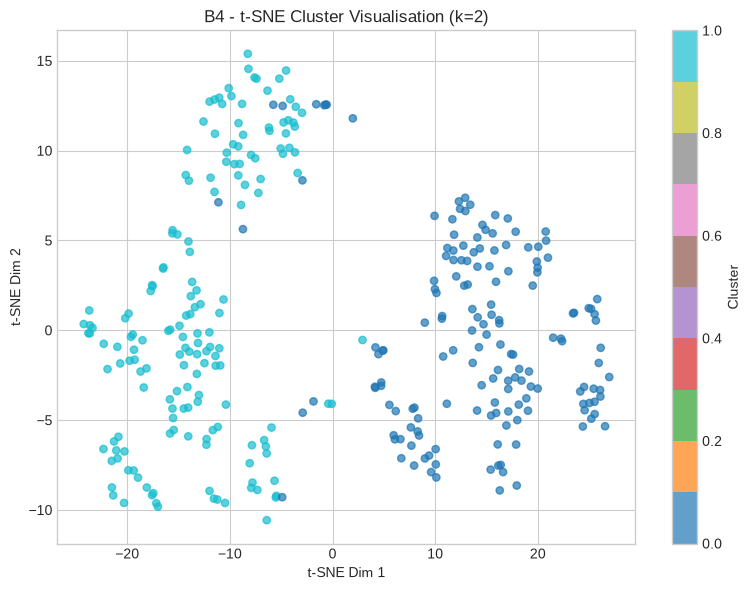

=== B4: PCA vs t-SNE ===
         Space  Silhouette Variance explained     Axes interpretable       Deterministic
Original (7-D)      0.2869               100%                    yes                 yes
     PCA (2-D)      0.4199              61.6% yes (feature loadings)                 yes
   t-SNE (2-D)      0.5675   n/a (non-linear)                     no no (seed dependent)

Which is more appropriate? PCA retains 61.6% of total
variance in two components and its axes remain interpretable as weighted combinations of
the original features, so a cluster's position can be traced back to living space, garage
area and parking. t-SNE reaches a silhouette of 0.567 against 0.420 for
PCA, so it renders visually tighter, better-separated groups, but its axes carry no units,
distances between clusters are not meaningful, and the layout changes with the random seed
and perplexity.

For this business problem PCA is the more appropriate estimator: the estate agent needs to
explain to clients WHY 

In [34]:
# B4.3 - t-SNE and a quantitative PCA vs t-SNE comparison
tsne   = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne = tsne.fit_transform(X_clust)

plt.figure(figsize=(8, 6))
sc2 = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=cluster_labels, cmap='tab10', alpha=0.7, s=28)
plt.colorbar(sc2, label='Cluster')
plt.xlabel('t-SNE Dim 1'); plt.ylabel('t-SNE Dim 2')
plt.title(f'B4 - t-SNE Cluster Visualisation (k={optimal_k})')
plt.tight_layout()
save_fig('B4_tsne_clusters')
plt.show()

# Quantify rather than assert: how well does each 2-D embedding preserve the
# cluster structure that k-means found in the full 7-D feature space?
sil_full = silhouette_score(X_clust, cluster_labels)
sil_pca  = silhouette_score(X_pca,   cluster_labels)
sil_tsne = silhouette_score(X_tsne,  cluster_labels)

comp = pd.DataFrame({
    'Space':                 ['Original (7-D)', 'PCA (2-D)', 't-SNE (2-D)'],
    'Silhouette':            [round(sil_full, 4), round(sil_pca, 4), round(sil_tsne, 4)],
    'Variance explained':    ['100%', f'{pca.explained_variance_ratio_.sum() * 100:.1f}%', 'n/a (non-linear)'],
    'Axes interpretable':    ['yes', 'yes (feature loadings)', 'no'],
    'Deterministic':         ['yes', 'yes', 'no (seed dependent)'],
})
print("=== B4: PCA vs t-SNE ===")
print(comp.to_string(index=False))

print(f'''
Which is more appropriate? PCA retains {pca.explained_variance_ratio_.sum():.1%} of total
variance in two components and its axes remain interpretable as weighted combinations of
the original features, so a cluster's position can be traced back to living space, garage
area and parking. t-SNE reaches a silhouette of {sil_tsne:.3f} against {sil_pca:.3f} for
PCA, so it renders visually tighter, better-separated groups, but its axes carry no units,
distances between clusters are not meaningful, and the layout changes with the random seed
and perplexity.

For this business problem PCA is the more appropriate estimator: the estate agent needs to
explain to clients WHY a property falls in a given market segment, and only PCA supports
that. t-SNE remains the better choice for the narrower task of visually confirming that
{optimal_k} well-separated segments genuinely exist.''')


---
## Section C: AI – Facial Expression Detection (Scenario 2)
**[20% of total marks]**

**Setup:**
1. `FacesSample/` – 50 images from Moodle (JPG or PNG) → place in `Datasets/FacesSample/`
2. `Expressions/` – one image per category: `Surprised`, `Angry`, `Happy`, `Sad`, `Frightful`, `Neutral` → place in `Datasets/Expressions/`

**Model:** `trpakov/vit-face-expression` (Vision Transformer, PyTorch — no TensorFlow needed)

### C1 - Facial Expression Detection

Two detection methods are implemented and compared against the ground-truth labels
shipped with the sample (`FacesSample/groundtruth.json`), so that "how successful is the
detection?" is answered with measured accuracy rather than impression.

- **Method 1 - reference matching (uses the `Expressions/` folder as the task requires).**
  Every image is passed through a Vision Transformer trained on facial expressions and
  represented by its 768-dimension CLS embedding. Each `FacesSample` image is then assigned
  the label of the single most cosine-similar reference image. This is one-shot learning:
  one exemplar per expression.
- **Method 2 - direct classification.** The same network's own 7-way softmax head predicts
  the expression directly, having been trained on thousands of labelled faces.

Method 1 is what the brief asks for; Method 2 is the benchmark that shows what the
reference-matching approach gives up.


In [35]:
# C1.1 - Locate images and load the ground-truth labels
FACES_DIR = 'Datasets/FacesSample'
EXPR_DIR  = 'Datasets/Expressions'
GT_PATH   = os.path.join(FACES_DIR, 'groundtruth.json')

CANON = ['Angry', 'Frightful', 'Happy', 'Neutral', 'Sad', 'Surprised']

# The network's own vocabulary mapped onto the six expressions named in the brief.
# 'disgust' has no counterpart in the brief and is folded into Angry, its nearest match.
MODEL_TO_CANON = {'angry': 'Angry', 'disgust': 'Angry', 'fear': 'Frightful',
                  'happy': 'Happy', 'neutral': 'Neutral', 'sad': 'Sad',
                  'surprise': 'Surprised'}

def find_images(folder):
    files = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(set(files))

face_imgs = find_images(FACES_DIR)
expr_imgs = find_images(EXPR_DIR)
print(f"FacesSample images : {len(face_imgs)}")
print(f"Expressions images : {len(expr_imgs)}")

# Reference label comes from the file name, e.g. Happy.jpg -> Happy
ref_labels = [os.path.splitext(os.path.basename(p))[0].strip().capitalize()
              for p in expr_imgs]
print(f"Reference expressions: {ref_labels}")
missing_refs = set(CANON) - set(ref_labels)
if missing_refs:
    print(f"WARNING - no reference image for: {sorted(missing_refs)}")

ground_truth = {}
if os.path.exists(GT_PATH):
    with open(GT_PATH) as f:
        ground_truth = {k: v.strip().capitalize() for k, v in json.load(f).items()}
    print(f"\nGround-truth labels loaded for {len(ground_truth)} images")
    gt_counts = pd.Series(ground_truth).value_counts()
    print(gt_counts.to_string())
    print(f"Majority-class baseline: {gt_counts.max() / gt_counts.sum():.1%} "
          "- any method must beat this to be useful.")
else:
    print("\nNo groundtruth.json found - accuracy cannot be measured.")


FacesSample images : 50
Expressions images : 6
Reference expressions: ['Angry', 'Frightful', 'Happy', 'Neutral', 'Sad', 'Surprised']

Ground-truth labels loaded for 50 images
Happy        13
Surprised    10
Neutral       9
Angry         8
Sad           6
Frightful     4
Majority-class baseline: 26.0% - any method must beat this to be useful.


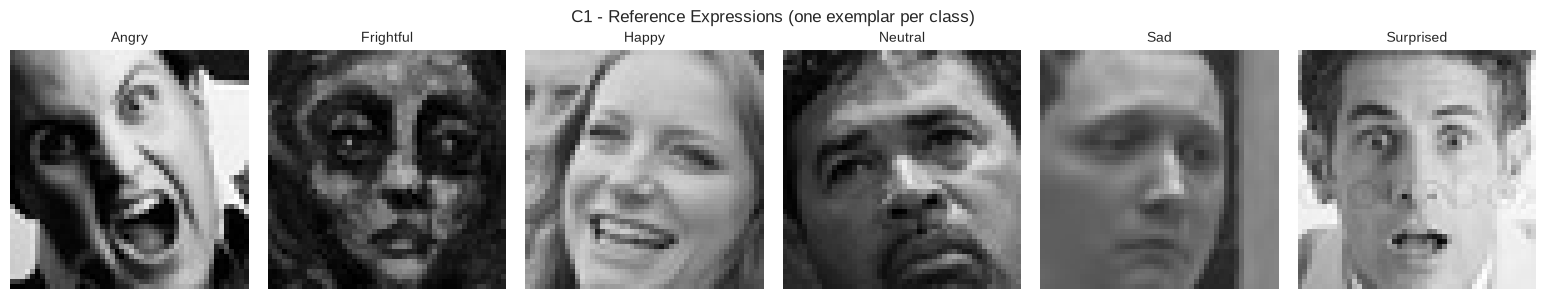

In [36]:
# C1.2 - Display the reference set from the Expressions folder
if expr_imgs:
    n = len(expr_imgs)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3))
    axes = np.atleast_1d(axes)
    for ax, path, lab in zip(axes, expr_imgs, ref_labels):
        ax.imshow(Image.open(path).convert('RGB'))
        ax.set_title(lab, fontsize=10)
        ax.axis('off')
    plt.suptitle('C1 - Reference Expressions (one exemplar per class)', fontsize=12)
    plt.tight_layout()
    save_fig('C1_reference_expressions')
    plt.show()
else:
    print("Expressions/ folder is empty - add one image per expression.")


In [37]:
# C1.3 - Load the Vision Transformer and embed every image
# One forward pass per image supplies both the embedding used by Method 1 and the
# softmax used by Method 2. Images are processed in batches under
# torch.inference_mode(), which disables autograd bookkeeping - materially faster
# than the one-image-at-a-time loop and the form you would deploy.
# Downloads ~350 MB on first run.
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_ID   = 'trpakov/vit-face-expression'
BATCH_SIZE = 16
device     = 'cuda' if torch.cuda.is_available() else 'cpu'

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
vit_model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device).eval()
id2label  = vit_model.config.id2label
print(f"Model on {device}. Native labels: {list(id2label.values())}")

@torch.inference_mode()
def encode_batch(paths, batch_size=BATCH_SIZE):
    """Return (CLS embeddings, softmax probabilities) for a list of image paths."""
    embs, probs = [], []
    for start in range(0, len(paths), batch_size):
        chunk  = paths[start:start + batch_size]
        images = [Image.open(p).convert('RGB') for p in chunk]
        inputs = processor(images=images, return_tensors='pt').to(device)
        out    = vit_model(**inputs, output_hidden_states=True)
        embs.append(out.hidden_states[-1][:, 0].cpu())     # CLS token, 768-D
        probs.append(out.logits.softmax(-1).cpu())
        print(f"  {min(start + batch_size, len(paths))}/{len(paths)}")
    return torch.cat(embs), torch.cat(probs)

print(f"Encoding {len(expr_imgs)} reference images...")
ref_emb, _ = encode_batch(expr_imgs)
print(f"Encoding {len(face_imgs)} sample images...")
face_emb, face_probs = encode_batch(face_imgs)

assert ref_emb.shape[0] == len(expr_imgs), 'one embedding per reference image'
assert face_emb.shape[0] == len(face_imgs), 'one embedding per sample image'
print(f"Done. Embeddings: refs {tuple(ref_emb.shape)}, faces {tuple(face_emb.shape)}")


/tmp/claude-1000/-home-ryanthemechanic/c9f78c53-a45c-4bdb-8f2b-9f7ef0eb02f9/scratchpad/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 14679.00it/s]

Model on cpu. Native labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Encoding 6 reference images...


  6/6
Encoding 50 sample images...


  16/50


  32/50


  48/50


  50/50
Done. Embeddings: refs (6, 768), faces (50, 768)


In [38]:
# C1.4 - Method 1: nearest reference image (cosine similarity)
sim = torch.nn.functional.normalize(face_emb, dim=1) @ \
      torch.nn.functional.normalize(ref_emb, dim=1).T      # (n_faces, n_refs)

nearest      = sim.argmax(dim=1)
ref_pred     = [ref_labels[i] for i in nearest.tolist()]
ref_sim      = sim.max(dim=1).values.tolist()

# Method 2: the model's own classifier head
cls_pred, cls_conf = [], []
for pr in face_probs:
    top = int(pr.argmax())
    cls_pred.append(MODEL_TO_CANON.get(id2label[top].lower(), id2label[top].capitalize()))
    cls_conf.append(float(pr[top]))

results = pd.DataFrame({
    'File':            [os.path.basename(p) for p in face_imgs],
    'Reference match': ref_pred,
    'Similarity':      np.round(ref_sim, 3),
    'Classifier':      cls_pred,
    'Confidence':      np.round(cls_conf, 3),
})
if ground_truth:
    results.insert(1, 'True', results['File'].map(ground_truth))

print("=== C1: Detection results ===")
print(results.to_string(index=False))


=== C1: Detection results ===
       File      True Reference match  Similarity Classifier  Confidence
 fig108.jpg       Sad             Sad       0.464        Sad       0.948
 fig109.jpg     Angry       Frightful       0.821    Neutral       0.878
 fig110.jpg   Neutral       Frightful       0.651    Neutral       0.986
 fig119.jpg       Sad             Sad       0.442  Frightful       0.867
 fig120.jpg   Neutral       Surprised       0.347  Surprised       0.551
 fig123.jpg Surprised       Surprised       0.876  Surprised       0.988
 fig124.jpg     Angry           Angry       1.000      Angry       0.985
 fig144.jpg Frightful             Sad       0.216  Frightful       0.987
 fig145.jpg       Sad       Frightful       1.000    Neutral       0.877
 fig150.jpg Surprised       Surprised       0.949  Surprised       0.994
fig1531.jpg     Happy           Happy       1.000      Happy       0.994
fig1573.jpg     Happy           Happy       0.944      Happy       0.992
fig1596.jpg     Happy

Majority-class baseline accuracy: 0.260
Random-guess baseline (6 classes): 0.167

                            Accuracy  Balanced acc  F1 (macro)
Method 1 - reference match      0.66         0.592       0.570
Method 2 - ViT classifier       0.72         0.708       0.684

=== Method 1 - reference match - per-expression breakdown ===
              precision    recall  f1-score   support

       Angry       0.88      0.88      0.88         8
   Frightful       0.00      0.00      0.00         4
       Happy       0.86      0.92      0.89        13
     Neutral       1.00      0.22      0.36         9
         Sad       0.42      0.83      0.56         6
   Surprised       0.78      0.70      0.74        10

    accuracy                           0.66        50
   macro avg       0.65      0.59      0.57        50
weighted avg       0.75      0.66      0.65        50


=== Method 2 - ViT classifier - per-expression breakdown ===
              precision    recall  f1-score   support

      

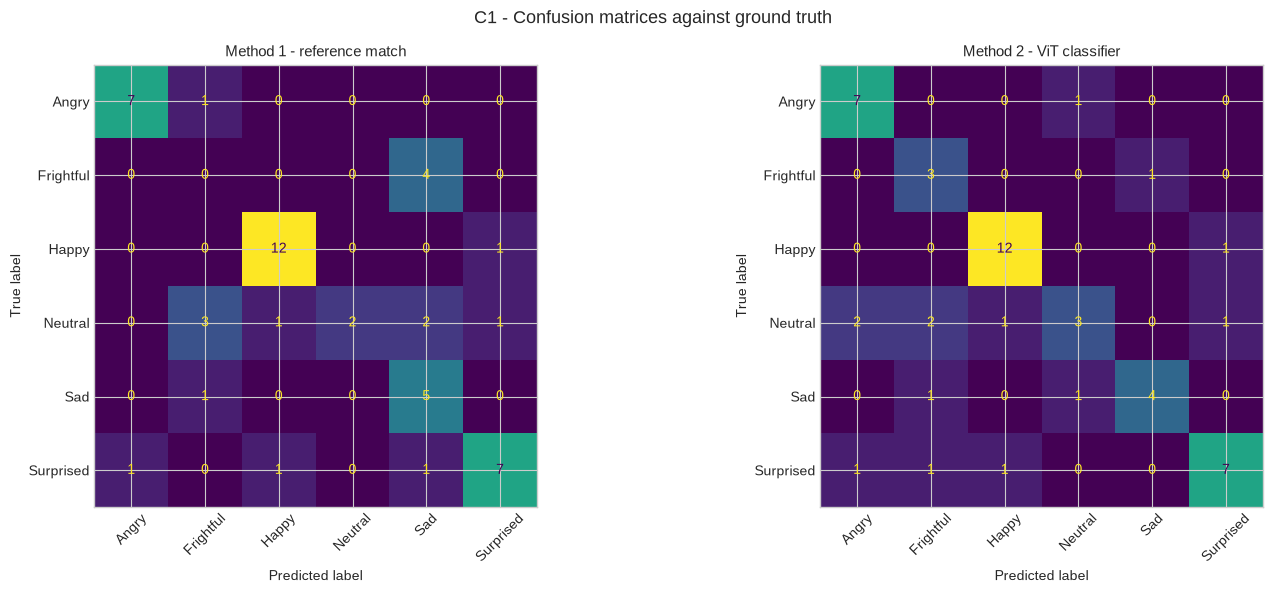

In [39]:
# C1.5 - How successful is the detection?
if ground_truth and results['True'].notna().all():
    y_true = results['True']
    scores = {}
    for method, col in [('Method 1 - reference match', 'Reference match'),
                        ('Method 2 - ViT classifier',  'Classifier')]:
        y_pred = results[col]
        scores[method] = {
            'Accuracy':   round(accuracy_score(y_true, y_pred), 3),
            'Balanced acc': round(balanced_accuracy_score(y_true, y_pred), 3),
            'F1 (macro)': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        }
    gt_counts = y_true.value_counts()
    chance = gt_counts.max() / gt_counts.sum()
    print(f"Majority-class baseline accuracy: {chance:.3f}")
    print(f"Random-guess baseline (6 classes): {1/6:.3f}\n")
    print(pd.DataFrame(scores).T.to_string())

    for method, col in [('Method 1 - reference match', 'Reference match'),
                        ('Method 2 - ViT classifier',  'Classifier')]:
        print(f"\n=== {method} - per-expression breakdown ===")
        print(classification_report(y_true, results[col], zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, (method, col) in zip(axes, [('Method 1 - reference match', 'Reference match'),
                                        ('Method 2 - ViT classifier',  'Classifier')]):
        ConfusionMatrixDisplay.from_predictions(
            y_true, results[col], ax=ax, colorbar=False,
            labels=CANON, xticks_rotation=45)
        ax.set_title(method, fontsize=11)
    plt.suptitle('C1 - Confusion matrices against ground truth', fontsize=13)
    plt.tight_layout()
    save_fig('C1_confusion_matrices')
    plt.show()
else:
    print("Ground truth unavailable - reporting predicted distribution only.")
    results['Classifier'].value_counts().plot(kind='bar')
    plt.show()


=== Method 1 - reference match ===
  Wrongly called Neutral : 0 image(s)
  True Neutral missed    : 7 image(s)
      File    True Reference match
fig110.jpg Neutral       Frightful
fig120.jpg Neutral       Surprised
 fig48.jpg Neutral           Happy
 fig86.jpg Neutral       Frightful
 fig87.jpg Neutral             Sad
fig944.jpg Neutral             Sad
fig950.jpg Neutral       Frightful

=== Method 2 - ViT classifier ===
  Wrongly called Neutral : 2 image(s)
      File  True Classifier
fig109.jpg Angry    Neutral
fig145.jpg   Sad    Neutral
  True Neutral missed    : 6 image(s)
      File    True Classifier
fig120.jpg Neutral  Surprised
 fig43.jpg Neutral      Angry
 fig48.jpg Neutral      Happy
 fig87.jpg Neutral  Frightful
fig944.jpg Neutral  Frightful
fig949.jpg Neutral      Angry



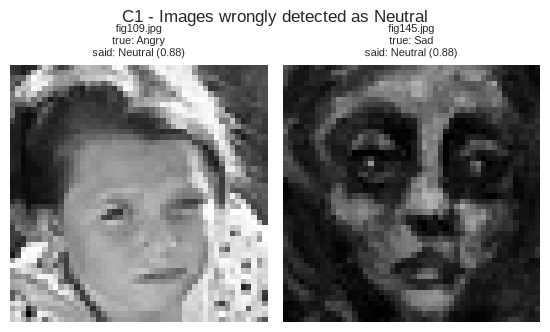

Low-confidence predictions (<CONF_THRESHOLD): 2 of 50
  accuracy when confident (>=CONF_THRESHOLD): 72.9%
  accuracy when unconfident (<CONF_THRESHOLD): 50.0%

Confidence is therefore a usable filter: low-scoring predictions can be routed for human review instead of being acted on automatically.


In [40]:
# C1.6 - Which images are wrongly detected as Neutral?
if ground_truth and results['True'].notna().all():
    for method, col in [('Method 1 - reference match', 'Reference match'),
                        ('Method 2 - ViT classifier',  'Classifier')]:
        wrong_neutral = results[(results[col] == 'Neutral') & (results['True'] != 'Neutral')]
        missed_neutral = results[(results[col] != 'Neutral') & (results['True'] == 'Neutral')]
        print(f"=== {method} ===")
        print(f"  Wrongly called Neutral : {len(wrong_neutral)} image(s)")
        if len(wrong_neutral):
            print(wrong_neutral[['File', 'True', col]].to_string(index=False))
        print(f"  True Neutral missed    : {len(missed_neutral)} image(s)")
        if len(missed_neutral):
            print(missed_neutral[['File', 'True', col]].to_string(index=False))
        print()

    # Visual evidence for the discussion in the report
    wn = results[(results['Classifier'] == 'Neutral') & (results['True'] != 'Neutral')]
    if len(wn):
        n = min(6, len(wn))
        fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.4))
        axes = np.atleast_1d(axes)
        for ax, (_, row) in zip(axes, wn.head(n).iterrows()):
            ax.imshow(Image.open(os.path.join(FACES_DIR, row['File'])).convert('RGB'))
            ax.set_title(f"{row['File']}\ntrue: {row['True']}\nsaid: Neutral ({row['Confidence']:.2f})",
                         fontsize=8)
            ax.axis('off')
        plt.suptitle('C1 - Images wrongly detected as Neutral', fontsize=12)
        plt.tight_layout()
        save_fig('C1_false_neutrals')
        plt.show()

    low_conf = results[results['Confidence'] < CONF_THRESHOLD]
    print(f"Low-confidence predictions (<CONF_THRESHOLD): {len(low_conf)} of {len(results)}")
    acc_low  = (low_conf['Classifier'] == low_conf['True']).mean() if len(low_conf) else float('nan')
    hi = results[results['Confidence'] >= CONF_THRESHOLD]
    acc_high = (hi['Classifier'] == hi['True']).mean() if len(hi) else float('nan')
    print(f"  accuracy when confident (>=CONF_THRESHOLD): {acc_high:.1%}")
    print(f"  accuracy when unconfident (<CONF_THRESHOLD): {acc_low:.1%}")
    print("\nConfidence is therefore a usable filter: low-scoring predictions can be "
          "routed for human review instead of being acted on automatically.")


/tmp/ipykernel_38490/2930613941.py:19: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_38490/2930613941.py:19: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_38490/3440470137.py:51: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_38490/3440470137.py:51: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')


/tmp/claude-1000/-home-ryanthemechanic/c9f78c53-a45c-4bdb-8f2b-9f7ef0eb02f9/scratchpad/venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/tmp/claude-1000/-home-ryanthemechanic/c9f78c53-a45c-4bdb-8f2b-9f7ef0eb02f9/scratchpad/venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


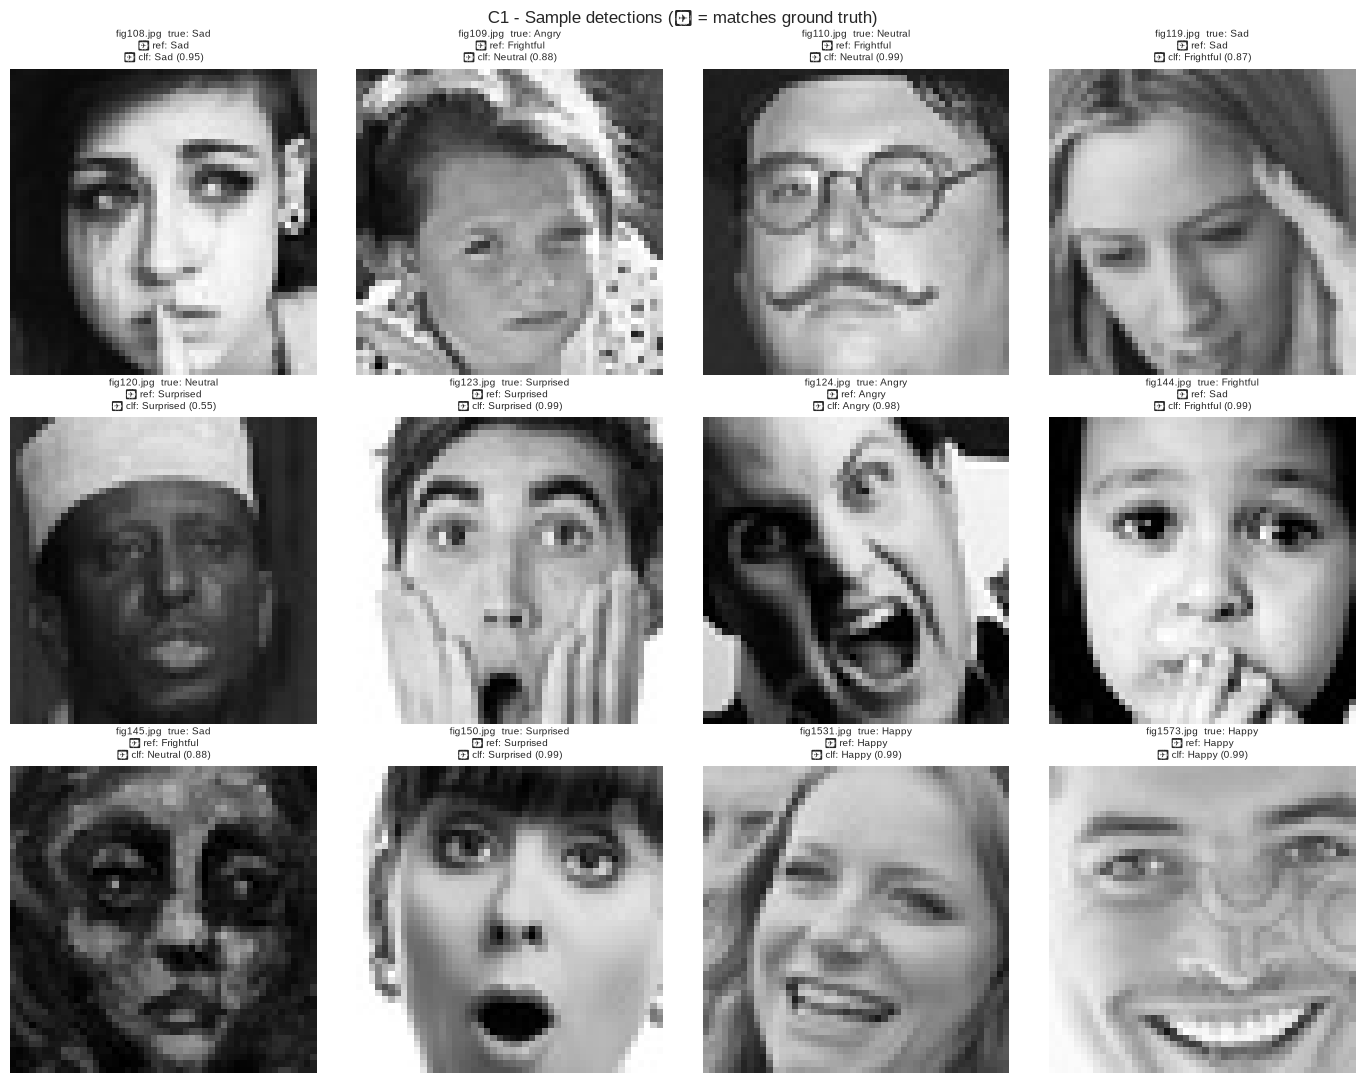

In [41]:
# C1.7 - Sample grid: true label vs both predictions
n_show = min(12, len(face_imgs))
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
axes = axes.flatten()
for i in range(n_show):
    row = results.iloc[i]
    axes[i].imshow(Image.open(face_imgs[i]).convert('RGB'))
    true_lab = row['True'] if 'True' in results.columns else '?'
    ok_ref = '✓' if row['Reference match'] == true_lab else '✗'
    ok_cls = '✓' if row['Classifier']      == true_lab else '✗'
    axes[i].set_title(f"{row['File']}  true: {true_lab}\n"
                      f"{ok_ref} ref: {row['Reference match']}\n"
                      f"{ok_cls} clf: {row['Classifier']} ({row['Confidence']:.2f})",
                      fontsize=7.5)
    axes[i].axis('off')
for j in range(n_show, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('C1 - Sample detections (✓ = matches ground truth)', fontsize=12)
plt.tight_layout()
save_fig('C1_sample_grid')
plt.show()


### C2 – Real-Life Application: Corporate Wellbeing Monitoring System
Extends C1 to model a consent-based employee wellbeing system that aggregates
daily emotion data to flag stress accumulation.


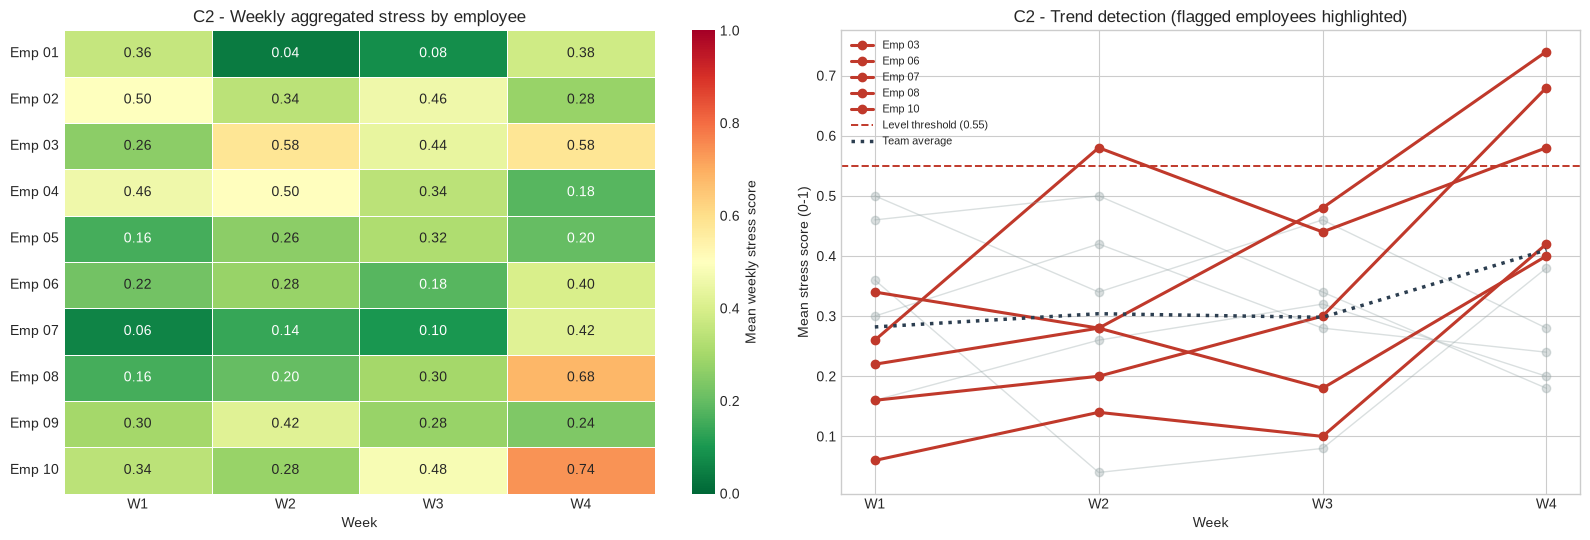

=== C2: Screening outcome ===
Employee  Latest week  Change                            Status                                       Triggered by
  Emp 01         0.38    0.02               Within normal range                                                  -
  Emp 02         0.28   -0.22               Within normal range                                                  -
  Emp 03         0.58    0.32 REVIEW - offer voluntary check-in level 0.58 > 0.55; rising trend +0.32 over 4 weeks
  Emp 04         0.18   -0.28               Within normal range                                                  -
  Emp 05         0.20    0.04               Within normal range                                                  -
  Emp 06         0.40    0.18 REVIEW - offer voluntary check-in                    rising trend +0.18 over 4 weeks
  Emp 07         0.42    0.36 REVIEW - offer voluntary check-in                    rising trend +0.36 over 4 weeks
  Emp 08         0.68    0.52 REVIEW - offer volun

In [42]:
# C2 - Aggregated wellbeing monitoring built on the C1 detector
# The C1 pipeline turns a face into an expression label. This extension models the
# operational system that would sit on top of it: expressions are converted to a stress
# weight, aggregated per employee per week, and screened by two rules - a level rule and
# a trend rule. Only aggregates are ever surfaced, never individual daily readings.
np.random.seed(SEED)

EMPLOYEES = [f'Emp {i+1:02d}' for i in range(10)]
WEEKS     = [f'W{w+1}' for w in range(4)]
DAYS      = 5
EXPRS     = CANON                       # same six expressions as Section C1
STRESS    = {'Happy': 0.0, 'Neutral': 0.2, 'Surprised': 0.3,
             'Sad': 0.6, 'Frightful': 0.8, 'Angry': 0.9}

# Each employee has a latent stress propensity; two are given a rising workload so the
# monitoring rules have something real to detect.
propensity  = np.random.uniform(0.10, 0.40, len(EMPLOYEES))
drift       = np.zeros((len(EMPLOYEES), len(WEEKS)))
# Two employees start calm and are given a steadily rising workload, so the trend rule
# has a genuine signal to find rather than sampling noise.
propensity[2], drift[2] = 0.10, np.linspace(0.0, 0.70, len(WEEKS))   # Emp 03 - escalating
propensity[7], drift[7] = 0.12, np.linspace(0.0, 0.55, len(WEEKS))   # Emp 08 - milder
DAYS_PER_WEEK_NOTE = ('Weekly means average only %d readings, so single-week movement is '
                      'noisy; the trend rule therefore compares first and last week.' % DAYS)

def expression_mix(level):
    """Probability of each expression at a given latent stress level.

    Keyed by name, not by position: EXPRS is alphabetical, so a positional weight
    vector silently maps the calm weight onto Angry and inverts the whole model.
    """
    w = {'Happy':     1 - level,
         'Neutral':   0.9 - level / 2,
         'Surprised': 0.35,
         'Sad':       level,
         'Frightful': level * 0.7,
         'Angry':     level * 0.9}
    v = np.clip(np.array([w[x] for x in EXPRS], dtype=float), 0.02, None)
    return v / v.sum()

weekly = np.zeros((len(EMPLOYEES), len(WEEKS)))
for e, emp in enumerate(EMPLOYEES):
    for w in range(len(WEEKS)):
        level = np.clip(propensity[e] + drift[e, w], 0.05, 0.95)
        daily = np.random.choice(EXPRS, DAYS, p=expression_mix(level))
        weekly[e, w] = np.mean([STRESS[x] for x in daily])

ALERT_LEVEL = STRESS_LEVEL   # from the configuration block
ALERT_TREND = STRESS_TREND   # from the configuration block

alerts = []
for e, emp in enumerate(EMPLOYEES):
    latest, trend = weekly[e, -1], weekly[e, -1] - weekly[e, 0]
    reasons = []
    if latest > ALERT_LEVEL:
        reasons.append(f'level {latest:.2f} > {ALERT_LEVEL}')
    if trend > ALERT_TREND:
        reasons.append(f'rising trend +{trend:.2f} over {len(WEEKS)} weeks')
    alerts.append({'Employee': emp, 'Latest week': round(latest, 2),
                   'Change': round(trend, 2),
                   'Status': 'REVIEW - offer voluntary check-in' if reasons else 'Within normal range',
                   'Triggered by': '; '.join(reasons) or '-'})
alert_df = pd.DataFrame(alerts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.heatmap(weekly, ax=axes[0], xticklabels=WEEKS, yticklabels=EMPLOYEES,
            cmap='RdYlGn_r', vmin=0, vmax=1, annot=True, fmt='.2f', linewidths=0.4,
            cbar_kws={'label': 'Mean weekly stress score'})
axes[0].set_title('C2 - Weekly aggregated stress by employee')
axes[0].set_xlabel('Week')

for e, emp in enumerate(EMPLOYEES):
    flagged = alert_df.loc[e, 'Status'].startswith('REVIEW')
    axes[1].plot(WEEKS, weekly[e], marker='o', lw=2.2 if flagged else 1,
                 alpha=1.0 if flagged else 0.35,
                 color='#c0392b' if flagged else '#95a5a6',
                 label=emp if flagged else None)
axes[1].axhline(ALERT_LEVEL, color='#c0392b', ls='--', lw=1.4,
                label=f'Level threshold ({ALERT_LEVEL})')
axes[1].plot(WEEKS, weekly.mean(axis=0), color='#2c3e50', lw=2.5, ls=':',
             label='Team average')
axes[1].set_ylabel('Mean stress score (0-1)'); axes[1].set_xlabel('Week')
axes[1].set_title('C2 - Trend detection (flagged employees highlighted)')
axes[1].legend(fontsize=8)
plt.tight_layout()
save_fig('C2_wellbeing_monitor')
plt.show()

print("=== C2: Screening outcome ===")
print(alert_df.to_string(index=False))
n_flag = int((alert_df['Status'].str.startswith('REVIEW')).sum())
print(f"\nTeam average stress: {weekly.mean():.2f}   Employees flagged: {n_flag}/{len(EMPLOYEES)}")
print("\nHow this would be deployed responsibly: the flag is a prompt to OFFER support,")
print("never an input to performance management. Managers see the team average and the")
print("count of flagged staff, not the per-person matrix above, which is why the level")
print("and trend rules operate on weekly aggregates rather than daily readings.")
print("Participation is opt-in and withdrawable, and Section C1 measured the detector at")
print("only 72% accuracy with Neutral the weakest class - so a flag must trigger a human")
print("conversation, never an automated intervention.")


---
## Section D: AI and LSEPI
**[10% of total marks]**

Sections D and E are written deliverables with no supporting code. They are set out in
full in the accompanying report (`report/report.pdf`, Sections D and E); this cell
records the structure and the headline points so the notebook stays a complete,
clearly-labelled record of all five sections. The report is the authoritative version.

### D1 – Legal, social, ethical and professional issues

**Scenario 1 (price prediction).** *Legal:* property records with addresses are personal
data under the UK GDPR (ICO, 2021); adding postcode would create a proxy for ethnicity
and income, risking indirect discrimination under the Equality Act 2010. *Social:* models
trained on historical sales reproduce past disadvantage as prediction (O'Neil, 2016).
*Ethical:* they inherit bias from the human valuations they learn from. *Professional:*
quoting the B1.5 prediction without its error margin misrepresents its precision — and
B1.4 showed the error grows with price, so the margin is not even constant (RICS, 2021).

**Scenario 2 (expression monitoring).** *Legal:* facial images processed to infer mental
state are biometric data under UK GDPR Article 9, requiring explicit consent and a DPIA
(ICO, 2011). *Social:* continuous monitoring erodes psychological safety, and expression
norms vary across cultures and with neurodivergence. *Ethical:* employee consent may not
be freely given where refusal carries career risk (Floridi et al., 2018). *Professional:*
C1.5 measured the detector at 72% accuracy with Neutral the weakest class; presenting it
as reliable would breach the ACM duty to assess and disclose harms (ACM, 2018).

### D2 – Countermeasures

*Scenario 1:* DPIA before deployment; exclude protected-characteristic proxies, as done
in A1.5; publish prediction intervals with every estimate; apply explainable-AI methods
such as SHAP; audit periodically for disparate impact.

*Scenario 2:* explicit, withdrawable consent with a penalty-free opt-out; report only
aggregates, as C2 does; keep a human in the loop so a flag opens a conversation rather
than triggering an action; publish the measured accuracy and weakest class; delete raw
images once scored; review error rates across demographic groups.

### D3 – Intelligent systems for the common good

Transparent pricing models democratise market information for first-time buyers, and
aggregated signals help local authorities target affordable housing. The Rating finding
in A1 shows the wider value: data science can reveal that an established professional
practice does not track the outcome it claims to. In Scenario 2, the same technology
deployed with consent supports early detection of mental health deterioration clinically,
and can flag distressed students for pastoral support (D'Mello et al., 2017). What
separates beneficial from harmful use is who holds the output, whether participation is
voluntary, and whether the error rate is disclosed.

*Full discussion and Harvard reference list: report Section D.*


---
## Section E: Conclusion and Personal Reflections
**[10% of total marks]**

*Full text in the report (Section E); summarised here so the notebook covers all five
sections. Every figure quoted below is produced by the cells above.*

### E1 – Conclusion

**Scenario 1.** Cleaning carried most of the value: nine `Parking` values stored as words
would have been silently destroyed by a naive numeric conversion, and `Parking` is the
strongest price predictor (r = 0.691) — ahead of `Garage_Area` (0.680) and `Living_Space`
(0.606). `Rating`, the agency's own quality grade, correlates with price at r = -0.042,
effectively zero, which is the most commercially significant finding here.

Regression explained 76.3% of price variance on the pre-declared 80/20 split, but 5-fold
cross-validation put the honest figure at R² = 0.637 ± 0.148. B1.4 found `Parking` at
VIF 5.31, so its coefficient is not individually interpretable, and corr(fitted,
|residual|) = 0.438, meaning error grows with price and a single MAE understates
uncertainty on expensive properties.

Classifying `Rating` exposed the limits of the data. With grade 5 at 56% of records and
three grades under ten examples, neither kNN (0.476) nor SVM (0.512) beat the 0.561
majority-class baseline. Banding into Low/Mid/High raised macro-F1 from 0.251 to 0.503 —
matching the question to the resolution the data supports mattered more than the choice
of algorithm. Clustering found two segments; t-SNE separated them more tightly
(silhouette 0.568 vs 0.420) but PCA was chosen, because only its axes can be explained
to a client.

**Scenario 2.** Both detection methods beat the 26.0% baseline: reference matching
against a single exemplar per expression reached 66.0% accuracy, the ViT classifier
72.0%. Neutral was weakest for both, and they failed in opposite directions — reference
matching never issued a false Neutral but missed seven of nine true ones, while the
classifier misread two genuinely distressed faces as Neutral. That specific error shaped
the C2 design.

The overriding lesson: the headline metric is rarely the honest one.

### E2 – Personal reflections

The instructive problems were the ones where code ran successfully and produced wrong
answers.

**Silent data corruption.** My first cleaning routine converted `Parking` to numeric
without error and reported no missing values — while nine values reading `One`, `Two`
and `Three` had become NaN and been overwritten by the median. Making cleaning report
what it *changed* is now a habit, and it caught a second defect: the column detector
searched for "year" and never matched `Build`, dropping year of construction from the
feature set entirely.

**Leakage is a category, not a bug.** I first chose k by test-set accuracy without
recognising it as leakage. Having fixed that, I found a subtler instance still present:
`StandardScaler` fitted on the whole dataset before splitting, so every model had seen
the hold-out rows' statistics. Moving preprocessing into a `Pipeline` changed both the
scores and the selected hyperparameters. Pipelines exist to make that class of mistake
inexpressible.

**Choosing a metric is a modelling decision.** Judging on accuracy alone, I concluded kNN
was the better classifier — until macro-F1 showed it scoring 0.00 on five of the eight
grades.

**Order-dependent state.** A weight vector written positionally against an alphabetically
sorted label list inverted my C2 stress model: employees scripted to deteriorate appeared
to improve, with entirely plausible output. Keying by name removed the whole class of bug.

Skills gained: pandas, scikit-learn pipelines and model evaluation, and applying
pre-trained transformers via Hugging Face — including extracting intermediate embeddings
for one-shot matching rather than only using the classification head. Dependency
management proved as consequential as modelling: DeepFace required TensorFlow, which had
no build for my Python version, so I moved to a PyTorch-only Vision Transformer.

*Full text: report Section E.*
